\begin{aligned}
\hat{H}_{total} &= \hat{H}_{bath} + \hat{H}_{piston} + \hat{H}_{int} \\
\hat{H}_{bath}(t) &= -\frac{J}{N}\hat{S}_z^2 - 2h_1\cos(\Omega_{1}t)\hat{S}_x - 2h_2\cos(\Omega_{2}t)\hat{S}_y  \\
\hat{H}_{piston} &= \omega_{p}\hat{b}^\dagger\hat{b}\, - \frac{u}{2}\hat{b}^\dagger\hat{b}^\dagger\hat{b}\hat{b} \\
\hat{H}_{int} &= \frac{g}{\sqrt{N}}(\hat{b}^\dagger\hat{S}_{-}\, + \hat{b}\hat{S}_{+})
\end{aligned}

Classical limit using the Holstein--Primakoff transformation :

The Holstein--Primakoff transformation is

\begin{equation}
\hat{S}_{+} = \sqrt{N-\hat{a}^\dagger\hat{a}}\, \hat{a},
\end{equation}

\begin{equation}
\hat{S}_{-} = \hat{a}^\dagger\sqrt{N-\hat{a}^\dagger\hat{a}},
\end{equation}

\begin{equation}
\hat{S}_{z} = \frac{N}{2} - \hat{a}^\dagger\hat{a}.
\end{equation}

Complete classical Hamiltonian :

\begin{equation}
\boxed{
\begin{aligned}
H_{\mathrm{cl}} = -\frac{J}{4}(q^2+p^2-1)^2 - h_1\cos(\Omega_1t)qA - h_2\cos(\Omega_2t)pA + \frac{\omega_p}{2}(X^2+P^2)
-\frac{u}{8}(X^2+P^2)^2 + \frac{g}{\sqrt{2}}A(Xq-Pp),
\end{aligned}
}
\end{equation}

where

\begin{equation}
\boxed{
A=\sqrt{2-q^2-p^2}.
}
\end{equation}

\begin{equation}
R^2=q^2+p^2,
\end{equation}

\begin{equation}
A=\sqrt{2-q^2-p^2}=\sqrt{2-R^2},
\end{equation}

\begin{equation}
D=Xq-Pp,
\end{equation}

\begin{equation}
c_1=\cos(\Omega_1 t),
\qquad
c_2=\cos(\Omega_2 t).
\end{equation}

Using Hamilton's equations,
\begin{equation}
\dot{q}=\frac{\partial H_{\rm cl}}{\partial p},
\qquad
\dot{p}=-\frac{\partial H_{\rm cl}}{\partial q},
\qquad
\dot{X}=\frac{\partial H_{\rm cl}}{\partial P},
\qquad
\dot{P}=-\frac{\partial H_{\rm cl}}{\partial X},
\end{equation}

we obtain
\begin{aligned}
\dot{q} &= -Jp(R^2-1) + \frac{h_1 p q}{A}\cos(\Omega_1 t) - h_2\cos(\Omega_2 t)\frac{(A^2-p^2)}{A} - \frac{gPA}{\sqrt{2}} -\frac{gpD}{\sqrt{2}A}, \\[6pt]
\dot{p} &= Jq(R^2-1) + h_1\cos(\Omega_1 t)\frac{(A^2-q^2)}{A} - \frac{h_2pq}{A}\cos(\Omega_2 t) - \frac{gXA}{\sqrt{2}}    +\frac{gqD}{\sqrt{2}A}, \\[6pt]
\dot{X} &= \omega_p P - \frac{u}{2}(X^2+P^2)P - \frac{gpA}{\sqrt{2}}, \\[6pt]
\dot{P} &= -\omega_p X + \frac{u}{2}(X^2+P^2)X - \frac{gqA}{\sqrt{2}}.
\end{aligned}


In [ ]:
import os
import numpy as np
from scipy.integrate import solve_ivp

def equations(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    dq = (-J*p*(R2-1)
          + h1*c1*p*q/A
          - h2*c2*(A2-p**2)/A
          - g*P*A/np.sqrt(2)
          - g*p*D/(np.sqrt(2)*A))

    dp = (J*q*(R2-1)
          + h1*c1*(A2-q**2)/A
          - h2*c2*p*q/A
          - g*X*A/np.sqrt(2)
          + g*q*D/(np.sqrt(2)*A))

    dX = (omega_p*P
          - (u/2)*(X**2+P**2)*P
          - g*p*A/np.sqrt(2))

    dP = (-omega_p*X
          + (u/2)*(X**2+P**2)*X
          - g*q*A/np.sqrt(2))

    return [dq, dp, dX, dP]

def dynamics(Omega1, Omega2):  

    bath_I = []
    bath_theta = []
    piston_I = []
    piston_theta = []

    for q0, p0, X0, P0 in initial_conditions:

        sol = solve_ivp(equations, (0, n_periods*T), [q0, p0, X0, P0], args=(Omega1, Omega2), method="DOP853", dense_output=True, rtol=1e-9, atol=1e-11, max_step=T/20)

        y = sol.sol(t_strobe)

        q = y[0]
        p = y[1]
        X = y[2]
        P = y[3]

        I_bath = (q**2 + p**2)/2
        theta_bath = np.mod(np.arctan2(p, q), 2*np.pi)

        I_piston = (X**2 + P**2)/2
        theta_piston = np.mod(np.arctan2(P, X), 2*np.pi)

        bath_I.append(I_bath)
        bath_theta.append(theta_bath)
        piston_I.append(I_piston)
        piston_theta.append(theta_piston)
    return bath_I, bath_theta, piston_I, piston_theta

Running Omega1 = 0.0, Omega2 = 0.0
Running Omega1 = 2.5, Omega2 = 2.0


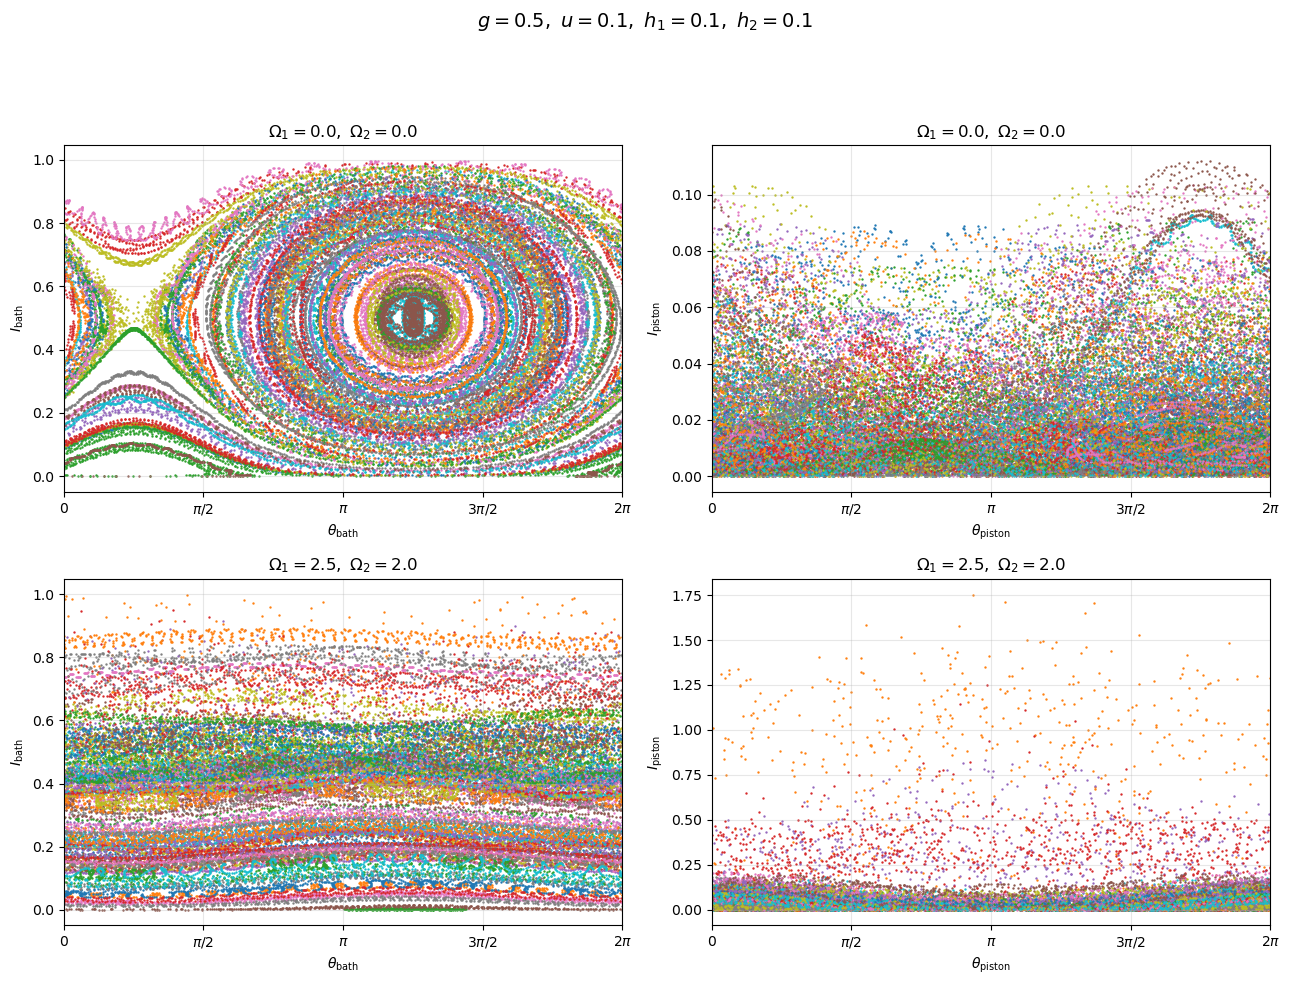

In [2]:
import matplotlib.pyplot as plt

J = 1.0
h1 = 0.1
h2 = 0.1
g = 0.5
omega_p = 2.5
u = 0.1
frequency_sets = [(0.0, 0.0), (2.5, 2.0)]
n_initial = 100
n_periods = 500
T = 4*np.pi
t_strobe = np.arange(n_periods + 1)*T

rng = np.random.default_rng(12345)
os.makedirs("action_angle_figures", exist_ok=True)

initial_conditions = []

for i in range(n_initial):

    q0 = rng.uniform(-0.99, 0.99)
    p0 = rng.uniform(-0.99, 0.99)
    X0 = rng.uniform(-0.15, 0.15)
    P0 = rng.uniform(-0.15, 0.15)

    initial_conditions.append([q0, p0, X0, P0])

initial_conditions = np.array(initial_conditions)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
k = 0
for Omega1, Omega2 in (frequency_sets):

    print(f"Running Omega1 = {Omega1}, Omega2 = {Omega2}")
    
    results = dynamics(Omega1, Omega2)

    bath_I = results[0]
    bath_theta = results[1]
    piston_I = results[2]
    piston_theta = results[3]

    for i in range(len(bath_I)):
        axes[k].scatter(bath_theta[i], bath_I[i], s=0.5)
    axes[k].set_xlabel(r"$\theta_{\rm bath}$")
    axes[k].set_ylabel(r"$I_{\rm bath}$")
    axes[k].set_title(rf"$\Omega_1={Omega1},\ \Omega_2={Omega2}$")

    axes[k].set_xlim(0, 2*np.pi)
    axes[k].set_xticks([0, 0.5*np.pi, np.pi, 1.5*np.pi, 2*np.pi])

    axes[k].set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])

    axes[k].grid(True, alpha=0.3)


    for i in range(len(piston_I)):
        axes[k+1].scatter(piston_theta[i], piston_I[i], s=0.5)
    axes[k+1].set_xlabel(r"$\theta_{\rm piston}$")
    axes[k+1].set_ylabel(r"$I_{\rm piston}$")
    axes[k+1].set_title(rf"$\Omega_1={Omega1},\ \Omega_2={Omega2}$")

    axes[k+1].set_xlim(0, 2*np.pi)

    axes[k+1].set_xticks([0, 0.5*np.pi, np.pi, 1.5*np.pi, 2*np.pi])

    axes[k+1].set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])

    axes[k+1].grid(True, alpha=0.3)

    k = k + 2


fig.suptitle(rf"$g={g},\ u={u},\ h_1={h1},\ h_2={h2}$", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.92])

filename = f"action_angle_g_{g}_u_{u}_h1_{h1}_h2_{h2}.png"
filepath = os.path.join("action_angle_figures", filename)
plt.savefig(filepath, dpi=300, bbox_inches="tight")
plt.show()     

Megno

In [1]:
import numpy as np
from scipy.integrate import solve_ivp

def equations(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    dq = (-J*p*(R2-1) + h1*c1*p*q/A - h2*c2*(A2-p**2)/A - g*P*A/np.sqrt(2) - g*p*D/(np.sqrt(2)*A))
    dp = (J*q*(R2-1) + h1*c1*(A2-q**2)/A - h2*c2*p*q/A - g*X*A/np.sqrt(2) + g*q*D/(np.sqrt(2)*A))
    dX = (omega_p*P - (u/2)*(X**2+P**2)*P - g*p*A/np.sqrt(2))
    dP = (-omega_p*X + (u/2)*(X**2+P**2)*X - g*q*A/np.sqrt(2))

    return np.array([dq, dp, dX, dP])

def jacobian(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    C = D/A

    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    Cq = X/A + D*q/A**3
    Cp = -P/A + D*p/A**3

    J11 = (-2*J*p*q + h1*c1*(p/A + p*q**2/A**3) + h2*c2*(q/A + p**2*q/A**3) + g*P*q/(np.sqrt(2)*A) - g*p*Cq/np.sqrt(2))

    J12 = (-J*(R2-1+2*p**2) + h1*c1*(q/A + p**2*q/A**3) + h2*c2*(3*p/A + p**3/A**3) + g*P*p/(np.sqrt(2)*A) - g*p*Cp/np.sqrt(2) - g*D/(np.sqrt(2)*A))

    J13 = -g*p*q/(np.sqrt(2)*A)
    J14 = -g*A/np.sqrt(2) + g*p**2/(np.sqrt(2)*A)

    J21 = (J*(R2-1+2*q**2) - h1*c1*(3*q/A + q**3/A**3) - h2*c2*(p/A + p*q**2/A**3) + g*X*q/(np.sqrt(2)*A) + g*(C + q*Cq)/np.sqrt(2))

    J22 = (2*J*p*q - h1*c1*(p/A + q**2*p/A**3) - h2*c2*(q/A + p**2*q/A**3) + g*X*p/(np.sqrt(2)*A) + g*q*Cp/np.sqrt(2))

    J23 = -g*A/np.sqrt(2) + g*q**2/(np.sqrt(2)*A)
    J24 = -g*q*p/(np.sqrt(2)*A)

    J31 = g*p*q/(np.sqrt(2)*A)
    J32 = -g*(A - p**2/A)/np.sqrt(2)
    J33 = -u*X*P
    J34 = omega_p - (u/2)*(X**2 + 3*P**2)

    J41 = -g*(A - q**2/A)/np.sqrt(2)
    J42 = g*p*q/(np.sqrt(2)*A)
    J43 = -omega_p + (u/2)*(3*X**2 + P**2)
    J44 = u*X*P

    return np.array([
        [J11, J12, J13, J14],
        [J21, J22, J23, J24],
        [J31, J32, J33, J34],
        [J41, J42, J43, J44]
    ])

def megno_equations(t, Y, Omega1, Omega2):

    y = Y[:4]
    delta = Y[4:8]
    Z = Y[8]

    dy = equations(t, y, Omega1, Omega2)
    M = jacobian(t, y, Omega1, Omega2)
    ddelta = M @ delta
    delta2 = np.dot(delta, delta)
    W = np.dot(delta, ddelta)/delta2
    dZ = t*W

    return np.concatenate((dy, ddelta, [dZ]))

def megno_dynamics(Omega1, Omega2):

    megno_values = []

    for q0, p0, X0, P0 in initial_conditions:

        delta0 = np.array([1e-6, 0.0, 0.0, 0.0])

        Y0 = np.concatenate(([q0, p0, X0, P0], delta0, [0.0]))

        sol = solve_ivp(megno_equations, (0, n_periods*T), Y0, args=(Omega1, Omega2), method="DOP853", t_eval=tlist, rtol=1e-9, atol=1e-11, max_step=T/20)

        print(i, sol.success, len(sol.t), sol.message)
        q = sol.y[0]
        p = sol.y[1]
        A2 = 2.0 - q**2 - p**2
        print("minimum A2 =", np.min(A2))
        Z = sol.y[8]
        Y_megno = 2*Z/sol.t

        Y_megno[0] = 0.0
        megno_values.append(Y_megno)
        

    return megno_values

Running Omega1 = 0, Omega2 = 0
9 True 501 The solver successfully reached the end of the integration interval.
minimum A2 = 0.23034861678238183


/tmp/ipykernel_7560/2348658440.py:100: RuntimeWarning: invalid value encountered in divide
  Y_megno = 2*Z/sol.t


9 True 501 The solver successfully reached the end of the integration interval.
minimum A2 = 0.04661528843139795
9 True 501 The solver successfully reached the end of the integration interval.
minimum A2 = 1.1422126518639544
9 True 501 The solver successfully reached the end of the integration interval.
minimum A2 = 0.24042719864725537
9 True 501 The solver successfully reached the end of the integration interval.
minimum A2 = 1.1332107474423796
9 True 501 The solver successfully reached the end of the integration interval.
minimum A2 = 0.850715317335685
9 True 501 The solver successfully reached the end of the integration interval.
minimum A2 = 0.05449912001780244
9 True 501 The solver successfully reached the end of the integration interval.
minimum A2 = 0.2606865016585135
9 True 501 The solver successfully reached the end of the integration interval.
minimum A2 = 4.438167980325147e-05
9 True 501 The solver successfully reached the end of the integration interval.
minimum A2 = 0.0327

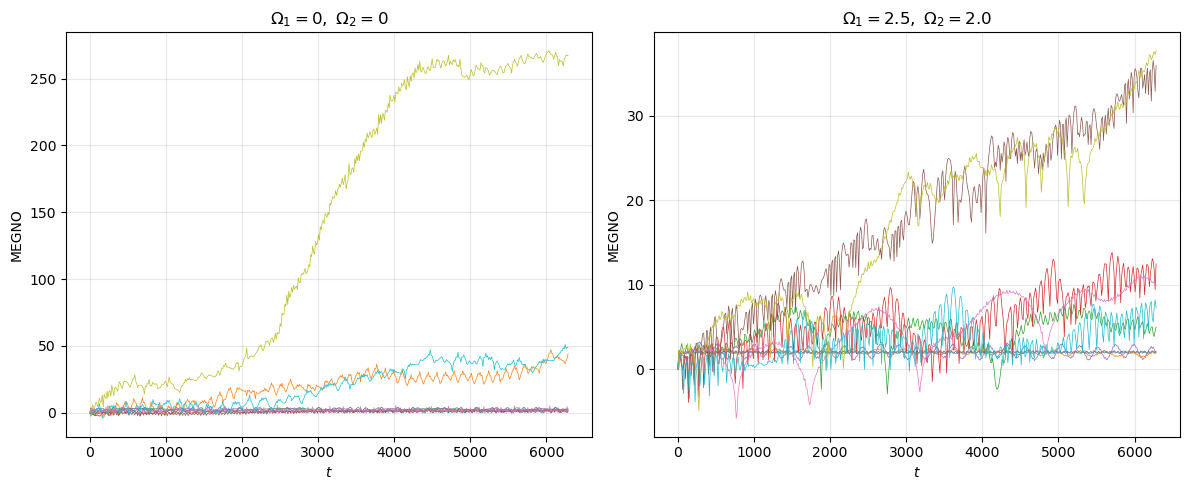

In [2]:
import os
import matplotlib.pyplot as plt


J = 1.0
h1 = 0.1
h2 = 0.1
g = 0.5
omega_p = 2.5
u = 0.1

frequency_sets = [(0, 0), (2.5, 2.0)]

n_initial = 10
n_periods = 500
T = 4*np.pi
tlist = np.linspace(0, n_periods*T, n_periods + 1)

rng = np.random.default_rng(12345)

initial_conditions = []

for i in range(n_initial):
    q0 = rng.uniform(-0.90, 0.90)
    p0 = rng.uniform(-0.90, 0.90)
    X0 = rng.uniform(-0.50, 0.50)
    P0 = rng.uniform(-0.50, 0.50)
    initial_conditions.append([q0, p0, X0, P0])

initial_conditions = np.array(initial_conditions)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for k, (Omega1, Omega2) in enumerate(frequency_sets):

    print(f"Running Omega1 = {Omega1}, Omega2 = {Omega2}")

    megno_values = megno_dynamics(Omega1, Omega2)

    for i in range(len(megno_values)):
        axes[k].plot(tlist, megno_values[i], linewidth=0.5)

    axes[k].set_xlabel(r"$t$")
    axes[k].set_ylabel("MEGNO")
    axes[k].set_title(rf"$\Omega_1={Omega1},\ \Omega_2={Omega2}$")
    axes[k].grid(True, alpha=0.3)

plt.tight_layout()

# os.makedirs("megno_figures", exist_ok=True)

# filename = "MEGNO_Omega1_0_0_Omega2_2_2.5.png"
# filepath = os.path.join("megno_figures", filename)
#plt.savefig(filepath, dpi=300, bbox_inches="tight")

plt.show()

Calculation of MEGNO

\begin{equation}
A=\sqrt{2-q^2-p^2}, \qquad D=Xq-Pp, \qquad C=\frac{D}{A}.
\end{equation}

\begin{equation}
C_q = \frac{X}{A} + \frac{Dq}{A^3},
\end{equation}

\begin{equation}
C_p = -\frac{P}{A} + \frac{Dp}{A^3}.
\end{equation}

Variational equations

\begin{equation}
\dot{\delta\mathbf{x}} = \mathcal{J}(t,\mathbf{x})\, \delta\mathbf{x},
\end{equation}

\begin{equation}
\delta\mathbf{x}
=
\begin{pmatrix}
\delta q\\
\delta p\\
\delta X\\
\delta P
\end{pmatrix}.
\end{equation}


Jacobian matrix

\begin{equation}
\mathcal{J}
=
\begin{pmatrix}
J_{11} & J_{12} & J_{13} & J_{14}\\
J_{21} & J_{22} & J_{23} & J_{24}\\
J_{31} & J_{32} & J_{33} & J_{34}\\
J_{41} & J_{42} & J_{43} & J_{44}
\end{pmatrix}.
\end{equation}


FIRST ROW

\begin{equation}
J_{11}=-2Jpq + h_1\cos(\Omega_1 t)\left(\frac{p}{A} + \frac{pq^2}{A^3}\right)
+ h_2\cos(\Omega_2 t) \left(\frac{q}{A} + \frac{p^2q}{A^3} \right) + \frac{gPq}{\sqrt{2}A} - \frac{gp}{\sqrt{2}}C_q ,
\end{equation}

\begin{equation}
J_{12} = -J\left(q^2+p^2-1+2p^2\right)
+ h_1\cos(\Omega_1 t)\left(\frac{q}{A} + \frac{p^2q}{A^3}\right)
+ h_2\cos(\Omega_2 t)\left(\frac{3p}{A} + \frac{p^3}{A^3}\right)
+ \frac{gPp}{\sqrt{2}A} - \frac{gp}{\sqrt{2}}C_p - \frac{gD}{\sqrt{2}A},
\end{equation}

\begin{equation}
J_{13} = -\frac{gpq}{\sqrt{2}A}, \qquad

J_{14} = -\frac{gA}{\sqrt{2}} + \frac{gp^2}{\sqrt{2}A}.
\end{equation}


SECOND ROW

\begin{equation}
J_{21} = J\left(q^2+p^2-1+2q^2\right)
- h_1\cos(\Omega_1 t)\left(\frac{3q}{A} + \frac{q^3}{A^3}\right)
- h_2\cos(\Omega_2 t)\left(\frac{p}{A} + \frac{pq^2}{A^3}\right)
+ \frac{gXq}{\sqrt{2}A} + \frac{g}{\sqrt{2}}\left(C+qC_q\right),
\end{equation}

\begin{equation}
J_{22}= 2Jpq 
- h_1\cos(\Omega_1 t)\left(\frac{p}{A} + \frac{q^2p}{A^3}\right)
- h_2\cos(\Omega_2 t)\left(\frac{q}{A} + \frac{p^2q}{A^3}\right)
+ \frac{gXp}{\sqrt{2}A} + \frac{gq}{\sqrt{2}}C_p ,
\end{equation}

\begin{equation}
J_{23} = -\frac{gA}{\sqrt{2}} + \frac{gq^2}{\sqrt{2}A}, \qquad

J_{24} = -\frac{gqp}{\sqrt{2}A}.
\end{equation}

THIRD ROW

\begin{equation}
J_{31} = \frac{gpq}{\sqrt{2}A}, \qquad

J_{32} = -\frac{g}{\sqrt{2}}\left(A-\frac{p^2}{A}\right), \qquad

J_{33} = -uXP, \qquad

J_{34} = \omega_p-\frac{u}{2}\left(X^2+3P^2\right).
\end{equation}

FOURTH ROW

\begin{equation}
J_{41} = -\frac{g}{\sqrt{2}}\left(A-\frac{q^2}{A}\right), \qquad

J_{42} = \frac{gpq}{\sqrt{2}A}, \qquad

J_{43} = -\omega_p + \frac{u}{2}\left(3X^2+P^2\right), \qquad

J_{44} = uXP.
\end{equation}

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp

def equations(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    dq = (-J*p*(R2-1) + h1*c1*p*q/A - h2*c2*(A2-p**2)/A - g*P*A/np.sqrt(2) - g*p*D/(np.sqrt(2)*A))
    dp = (J*q*(R2-1) + h1*c1*(A2-q**2)/A - h2*c2*p*q/A - g*X*A/np.sqrt(2) + g*q*D/(np.sqrt(2)*A))
    dX = (omega_p*P - (u/2)*(X**2+P**2)*P - g*p*A/np.sqrt(2))
    dP = (-omega_p*X + (u/2)*(X**2+P**2)*X - g*q*A/np.sqrt(2))

    return np.array([dq, dp, dX, dP])

def jacobian(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    C = D/A

    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    Cq = X/A + D*q/A**3
    Cp = -P/A + D*p/A**3

    J11 = (-2*J*p*q + h1*c1*(p/A + p*q**2/A**3) + h2*c2*(q/A + p**2*q/A**3) + g*P*q/(np.sqrt(2)*A) - g*p*Cq/np.sqrt(2))

    J12 = (-J*(R2-1+2*p**2) + h1*c1*(q/A + p**2*q/A**3) + h2*c2*(3*p/A + p**3/A**3) + g*P*p/(np.sqrt(2)*A) - g*p*Cp/np.sqrt(2) - g*D/(np.sqrt(2)*A))

    J13 = -g*p*q/(np.sqrt(2)*A)
    J14 = -g*A/np.sqrt(2) + g*p**2/(np.sqrt(2)*A)

    J21 = (J*(R2-1+2*q**2) - h1*c1*(3*q/A + q**3/A**3) - h2*c2*(p/A + p*q**2/A**3) + g*X*q/(np.sqrt(2)*A) + g*(C + q*Cq)/np.sqrt(2))

    J22 = (2*J*p*q - h1*c1*(p/A + q**2*p/A**3) - h2*c2*(q/A + p**2*q/A**3) + g*X*p/(np.sqrt(2)*A) + g*q*Cp/np.sqrt(2))

    J23 = -g*A/np.sqrt(2) + g*q**2/(np.sqrt(2)*A)
    J24 = -g*q*p/(np.sqrt(2)*A)

    J31 = g*p*q/(np.sqrt(2)*A)
    J32 = -g*(A - p**2/A)/np.sqrt(2)
    J33 = -u*X*P
    J34 = omega_p - (u/2)*(X**2 + 3*P**2)

    J41 = -g*(A - q**2/A)/np.sqrt(2)
    J42 = g*p*q/(np.sqrt(2)*A)
    J43 = -omega_p + (u/2)*(3*X**2 + P**2)
    J44 = u*X*P

    return np.array([
        [J11, J12, J13, J14],
        [J21, J22, J23, J24],
        [J31, J32, J33, J34],
        [J41, J42, J43, J44]
    ])

def megno_equations(t, Y, Omega1, Omega2):

    y = Y[:4]
    delta = Y[4:8]
    Z = Y[8]

    dy = equations(t, y, Omega1, Omega2)
    M = jacobian(t, y, Omega1, Omega2)
    ddelta = M @ delta
    delta2 = np.dot(delta, delta)
    W = np.dot(delta, ddelta)/delta2
    dZ = t*W

    return np.concatenate((dy, ddelta, [dZ]))

def megno_dynamics(Omega1, Omega2):

    megno_values = []

    for i, (q0, p0, X0, P0) in enumerate(initial_conditions):

        delta0 = np.array([1e-6, 0.0, 0.0, 0.0])

        Y0 = np.concatenate(([q0, p0, X0, P0], delta0, [0.0]))

        sol = solve_ivp(megno_equations, (0, n_periods*T), Y0, args=(Omega1, Omega2), method="DOP853", t_eval=tlist, rtol=1e-9, atol=1e-11, max_step=T/20)

        print(i, sol.success, len(sol.t), sol.message)
        # q = sol.y[0]
        # p = sol.y[1]
        # A2 = 2.0 - q**2 - p**2
        # print("minimum A2 =", np.min(A2))
        if sol.success:
            Z = sol.y[8]
            Y_megno = np.zeros_like(sol.t)
            Y_megno[1:] = 2*Z[1:]/sol.t[1:]
            megno_final = Y_megno[-1]
        else:
            megno_final = np.nan  # or some other value indicating failure    

        megno_values.append(megno_final)
        

    return megno_values

In [ ]:
import os
import matplotlib.pyplot as plt


J = 1.0
h1 = 0.1
h2 = 0.1
g = 0.5
omega_p = 2.5
u = 0.1

frequency_sets = [(0, 0), (2.5, 2.0)]

n_initial = 100
n_periods = 500
T = 4*np.pi
tlist = np.linspace(0, n_periods*T, n_periods + 1)

rng = np.random.default_rng(12345)

initial_conditions = []

for i in range(n_initial):
    q0 = rng.uniform(-0.90, 0.90)
    p0 = rng.uniform(-0.90, 0.90)
    X0 = rng.uniform(-0.15, 0.15)
    P0 = rng.uniform(-0.15, 0.15)
    initial_conditions.append([q0, p0, X0, P0])

initial_conditions = np.array(initial_conditions)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for k, (Omega1, Omega2) in enumerate(frequency_sets):

    print(f"Running Omega1 = {Omega1}, Omega2 = {Omega2}")

    megno_values = megno_dynamics(Omega1, Omega2)
    ic_number = np.arange(1, n_initial + 1)

    axes[k].scatter(ic_number, megno_values, s=10)
    axes[k].set_xlabel("initial condition number")
    axes[k].set_ylabel("Final MEGNO")
    axes[k].set_title(rf"$\Omega_1={Omega1},\ \Omega_2={Omega2}$")
    axes[k].grid(True, alpha=0.3)

fig.suptitle(rf"$g={g}, u={u}, h_1={h1}, h_2={h2}$" rf"$\Omega_1={Omega1},\Omega_2={Omega2},\ "rf"T={T:.4f}$", fontsize=14)
plt.tight_layout()

os.makedirs("megno_figures", exist_ok=True)
filename = f"MEGNO_Final_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_h1_{h1}_h2_{h2}.png"
filepath = os.path.join("megno_figures", filename)
plt.savefig(filepath, dpi=300, bbox_inches="tight")

plt.show()

Running Omega1 = 0, Omega2 = 0
0 True 501 The solver successfully reached the end of the integration interval.


Initial conditions for X_0, P_0 = (-.50, +.50)

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp

def equations(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    dq = (-J*p*(R2-1) + h1*c1*p*q/A - h2*c2*(A2-p**2)/A - g*P*A/np.sqrt(2) - g*p*D/(np.sqrt(2)*A))
    dp = (J*q*(R2-1) + h1*c1*(A2-q**2)/A - h2*c2*p*q/A - g*X*A/np.sqrt(2) + g*q*D/(np.sqrt(2)*A))
    dX = (omega_p*P - (u/2)*(X**2+P**2)*P - g*p*A/np.sqrt(2))
    dP = (-omega_p*X + (u/2)*(X**2+P**2)*X - g*q*A/np.sqrt(2))

    return np.array([dq, dp, dX, dP])

def jacobian(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    C = D/A

    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    Cq = X/A + D*q/A**3
    Cp = -P/A + D*p/A**3

    J11 = (-2*J*p*q + h1*c1*(p/A + p*q**2/A**3) + h2*c2*(q/A + p**2*q/A**3) + g*P*q/(np.sqrt(2)*A) - g*p*Cq/np.sqrt(2))

    J12 = (-J*(R2-1+2*p**2) + h1*c1*(q/A + p**2*q/A**3) + h2*c2*(3*p/A + p**3/A**3) + g*P*p/(np.sqrt(2)*A) - g*p*Cp/np.sqrt(2) - g*D/(np.sqrt(2)*A))

    J13 = -g*p*q/(np.sqrt(2)*A)
    J14 = -g*A/np.sqrt(2) + g*p**2/(np.sqrt(2)*A)

    J21 = (J*(R2-1+2*q**2) - h1*c1*(3*q/A + q**3/A**3) - h2*c2*(p/A + p*q**2/A**3) + g*X*q/(np.sqrt(2)*A) + g*(C + q*Cq)/np.sqrt(2))

    J22 = (2*J*p*q - h1*c1*(p/A + q**2*p/A**3) - h2*c2*(q/A + p**2*q/A**3) + g*X*p/(np.sqrt(2)*A) + g*q*Cp/np.sqrt(2))

    J23 = -g*A/np.sqrt(2) + g*q**2/(np.sqrt(2)*A)
    J24 = -g*q*p/(np.sqrt(2)*A)

    J31 = g*p*q/(np.sqrt(2)*A)
    J32 = -g*(A - p**2/A)/np.sqrt(2)
    J33 = -u*X*P
    J34 = omega_p - (u/2)*(X**2 + 3*P**2)

    J41 = -g*(A - q**2/A)/np.sqrt(2)
    J42 = g*p*q/(np.sqrt(2)*A)
    J43 = -omega_p + (u/2)*(3*X**2 + P**2)
    J44 = u*X*P

    return np.array([
        [J11, J12, J13, J14],
        [J21, J22, J23, J24],
        [J31, J32, J33, J34],
        [J41, J42, J43, J44]
    ])

def megno_equations(t, Y, Omega1, Omega2):

    y = Y[:4]
    delta = Y[4:8]
    Z = Y[8]

    dy = equations(t, y, Omega1, Omega2)
    M = jacobian(t, y, Omega1, Omega2)
    ddelta = M @ delta
    delta2 = np.dot(delta, delta)
    W = np.dot(delta, ddelta)/delta2
    dZ = t*W

    return np.concatenate((dy, ddelta, [dZ]))

def megno_dynamics(Omega1, Omega2):

    megno_values = []

    for i, (q0, p0, X0, P0) in enumerate(initial_conditions):

        delta0 = np.array([1e-6, 0.0, 0.0, 0.0])

        Y0 = np.concatenate(([q0, p0, X0, P0], delta0, [0.0]))

        sol = solve_ivp(megno_equations, (0, n_periods*T), Y0, args=(Omega1, Omega2), method="DOP853", t_eval=tlist, rtol=1e-9, atol=1e-11, max_step=T/20)

        print(i, sol.success, len(sol.t), sol.message)
        # q = sol.y[0]
        # p = sol.y[1]
        # A2 = 2.0 - q**2 - p**2
        # print("minimum A2 =", np.min(A2))
        if sol.success:
            Z = sol.y[8]
            Y_megno = np.zeros_like(sol.t)
            Y_megno[1:] = 2*Z[1:]/sol.t[1:]
            megno_final = Y_megno[-1]
        else:
            megno_final = np.nan  # or some other value indicating failure    

        megno_values.append(megno_final)
        

    return megno_values

Running Omega1 = 0, Omega2 = 0
0 True 501 The solver successfully reached the end of the integration interval.
1 True 501 The solver successfully reached the end of the integration interval.
2 True 501 The solver successfully reached the end of the integration interval.
3 True 501 The solver successfully reached the end of the integration interval.
4 True 501 The solver successfully reached the end of the integration interval.
5 True 501 The solver successfully reached the end of the integration interval.
6 True 501 The solver successfully reached the end of the integration interval.
7 True 501 The solver successfully reached the end of the integration interval.
8 True 501 The solver successfully reached the end of the integration interval.
9 True 501 The solver successfully reached the end of the integration interval.
10 True 501 The solver successfully reached the end of the integration interval.
11 True 501 The solver successfully reached the end of the integration interval.
12 True

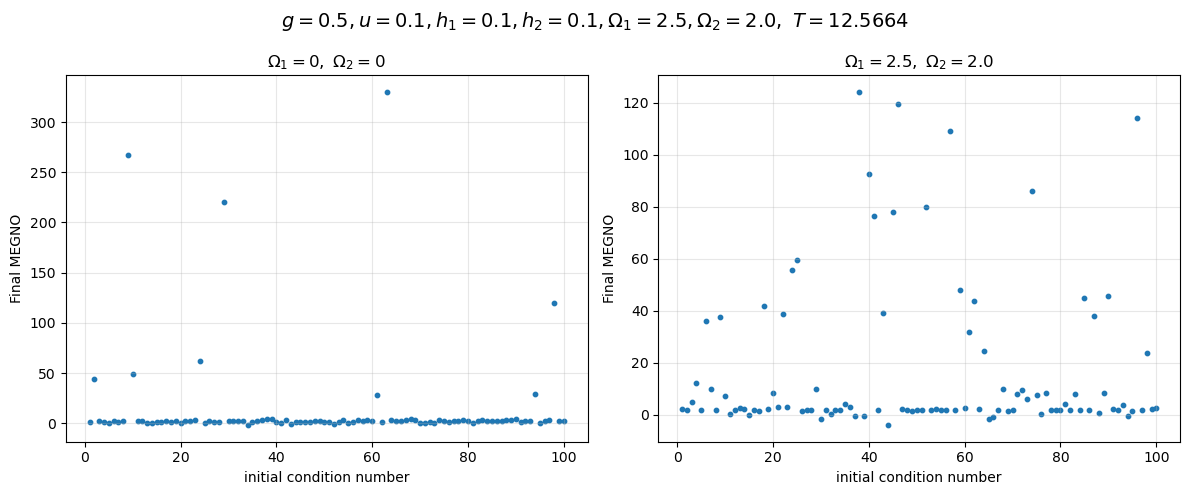

In [ ]:
import os
import matplotlib.pyplot as plt


J = 1.0
h1 = 0.1
h2 = 0.1
g = 0.5
omega_p = 2.5
u = 0.1

frequency_sets = [(0, 0), (2.5, 2.0)]

n_initial = 100
n_periods = 500
T = 4*np.pi
tlist = np.linspace(0, n_periods*T, n_periods + 1)

rng = np.random.default_rng(12345)

initial_conditions = []

for i in range(n_initial):
    q0 = rng.uniform(-0.90, 0.90)
    p0 = rng.uniform(-0.90, 0.90)
    X0 = rng.uniform(-0.50, 0.50)
    P0 = rng.uniform(-0.50, 0.50)
    initial_conditions.append([q0, p0, X0, P0])

initial_conditions = np.array(initial_conditions)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for k, (Omega1, Omega2) in enumerate(frequency_sets):

    print(f"Running Omega1 = {Omega1}, Omega2 = {Omega2}")

    megno_values = megno_dynamics(Omega1, Omega2)
    ic_number = np.arange(1, n_initial + 1)

    axes[k].scatter(ic_number, megno_values, s=10)
    axes[k].set_xlabel("initial condition number")
    axes[k].set_ylabel("Final MEGNO")
    axes[k].set_title(rf"$\Omega_1={Omega1},\ \Omega_2={Omega2}$")
    axes[k].grid(True, alpha=0.3)

fig.suptitle(rf"$g={g}, u={u}, h_1={h1}, h_2={h2},$" rf"$\Omega_1={Omega1},\Omega_2={Omega2},\ "rf"T={T:.4f}$", fontsize=14)
plt.tight_layout()

os.makedirs("megno_figures", exist_ok=True)
filename = f"MEGNO_Final_IC_2nd_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_h1_{h1}_h2_{h2}.png"
filepath = os.path.join("megno_figures", filename)
plt.savefig(filepath, dpi=300, bbox_inches="tight")

plt.show()

Chaotic IC selection

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp

def equations(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    dq = (-J*p*(R2-1) + h1*c1*p*q/A - h2*c2*(A2-p**2)/A - g*P*A/np.sqrt(2) - g*p*D/(np.sqrt(2)*A))
    dp = (J*q*(R2-1) + h1*c1*(A2-q**2)/A - h2*c2*p*q/A - g*X*A/np.sqrt(2) + g*q*D/(np.sqrt(2)*A))
    dX = (omega_p*P - (u/2)*(X**2+P**2)*P - g*p*A/np.sqrt(2))
    dP = (-omega_p*X + (u/2)*(X**2+P**2)*X - g*q*A/np.sqrt(2))

    return np.array([dq, dp, dX, dP])

def jacobian(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    C = D/A

    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    Cq = X/A + D*q/A**3
    Cp = -P/A + D*p/A**3

    J11 = (-2*J*p*q + h1*c1*(p/A + p*q**2/A**3) + h2*c2*(q/A + p**2*q/A**3) + g*P*q/(np.sqrt(2)*A) - g*p*Cq/np.sqrt(2))

    J12 = (-J*(R2-1+2*p**2) + h1*c1*(q/A + p**2*q/A**3) + h2*c2*(3*p/A + p**3/A**3) + g*P*p/(np.sqrt(2)*A) - g*p*Cp/np.sqrt(2) - g*D/(np.sqrt(2)*A))

    J13 = -g*p*q/(np.sqrt(2)*A)
    J14 = -g*A/np.sqrt(2) + g*p**2/(np.sqrt(2)*A)

    J21 = (J*(R2-1+2*q**2) - h1*c1*(3*q/A + q**3/A**3) - h2*c2*(p/A + p*q**2/A**3) + g*X*q/(np.sqrt(2)*A) + g*(C + q*Cq)/np.sqrt(2))

    J22 = (2*J*p*q - h1*c1*(p/A + q**2*p/A**3) - h2*c2*(q/A + p**2*q/A**3) + g*X*p/(np.sqrt(2)*A) + g*q*Cp/np.sqrt(2))

    J23 = -g*A/np.sqrt(2) + g*q**2/(np.sqrt(2)*A)
    J24 = -g*q*p/(np.sqrt(2)*A)

    J31 = g*p*q/(np.sqrt(2)*A)
    J32 = -g*(A - p**2/A)/np.sqrt(2)
    J33 = -u*X*P
    J34 = omega_p - (u/2)*(X**2 + 3*P**2)

    J41 = -g*(A - q**2/A)/np.sqrt(2)
    J42 = g*p*q/(np.sqrt(2)*A)
    J43 = -omega_p + (u/2)*(3*X**2 + P**2)
    J44 = u*X*P

    return np.array([
        [J11, J12, J13, J14],
        [J21, J22, J23, J24],
        [J31, J32, J33, J34],
        [J41, J42, J43, J44]
    ])

def megno_equations(t, Y, Omega1, Omega2):

    y = Y[:4]
    delta = Y[4:8]
    Z = Y[8]

    dy = equations(t, y, Omega1, Omega2)
    M = jacobian(t, y, Omega1, Omega2)
    ddelta = M @ delta
    delta2 = np.dot(delta, delta)
    W = np.dot(delta, ddelta)/delta2
    dZ = t*W

    return np.concatenate((dy, ddelta, [dZ]))

def megno_dynamics(Omega1, Omega2):

    megno_values = []

    for i, (q0, p0, X0, P0) in enumerate(initial_conditions):

        delta0 = np.array([1e-6, 0.0, 0.0, 0.0])

        Y0 = np.concatenate(([q0, p0, X0, P0], delta0, [0.0]))

        sol = solve_ivp(megno_equations, (0, n_periods*T), Y0, args=(Omega1, Omega2), method="DOP853", t_eval=tlist, rtol=1e-9, atol=1e-11, max_step=T/20)

        #print(i, sol.success, len(sol.t), sol.message)
        # q = sol.y[0]
        # p = sol.y[1]
        # A2 = 2.0 - q**2 - p**2
        # print("minimum A2 =", np.min(A2))
        if sol.success:
            Z = sol.y[8]
            Y_megno = np.zeros_like(sol.t)
            Y_megno[1:] = 2*Z[1:]/sol.t[1:]
            megno_final = Y_megno[-1]
        else:
            megno_final = np.nan  # or some other value indicating failure    

        megno_values.append(megno_final)

        

    return np.array(megno_values)

def chaotic_energy(Omega1, Omega2, chaotic_indices):

    energies = []

    for i in chaotic_indices:

        q0, p0, X0, P0 = initial_conditions[i]

        sol = solve_ivp(equations, (0, n_periods*T), [q0, p0, X0, P0], args=(Omega1, Omega2), method="DOP853", t_eval=tlist, rtol=1e-9, atol=1e-11, max_step=T/20)

        if sol.success:

            X = sol.y[2]
            P = sol.y[3]

            E = ((omega_p/2)*(X**2 + P**2) - (u/8)*(X**2 + P**2)**2)

        else:

            print(f"Energy integration failed for IC {i+1}: {sol.message}")
            E = np.full(len(tlist), np.nan)

        energies.append(E)

    return np.array(energies)

Running Omega1 = 0, Omega2 = 0
Number of chaotic ICs: 9
Chaotic IC numbers: [ 2  9 10 24 29 61 63 94 98]

Omega1 = 0, Omega2 = 0
Number of chaotic ICs = 9
Slope = -3.200398750516375
R² = 0.9019511387686938
Effective beta = 3.200398750516375
Effective temperature = 0.31246106437163584
Running Omega1 = 2.5, Omega2 = 2.0
Number of chaotic ICs: 25
Chaotic IC numbers: [ 4  6  9 18 22 24 25 38 40 41 43 45 46 52 57 59 61 62 64 74 85 87 90 96
 98]


/tmp/ipykernel_12721/2839825170.py:9: RuntimeWarning: invalid value encountered in sqrt
  A = np.sqrt(A2)



Omega1 = 2.5, Omega2 = 2.0
Number of chaotic ICs = 25
Slope = -1.5237968558967192
R² = 0.9042150534223976
Effective beta = 1.5237968558967192
Effective temperature = 0.6562554556601464


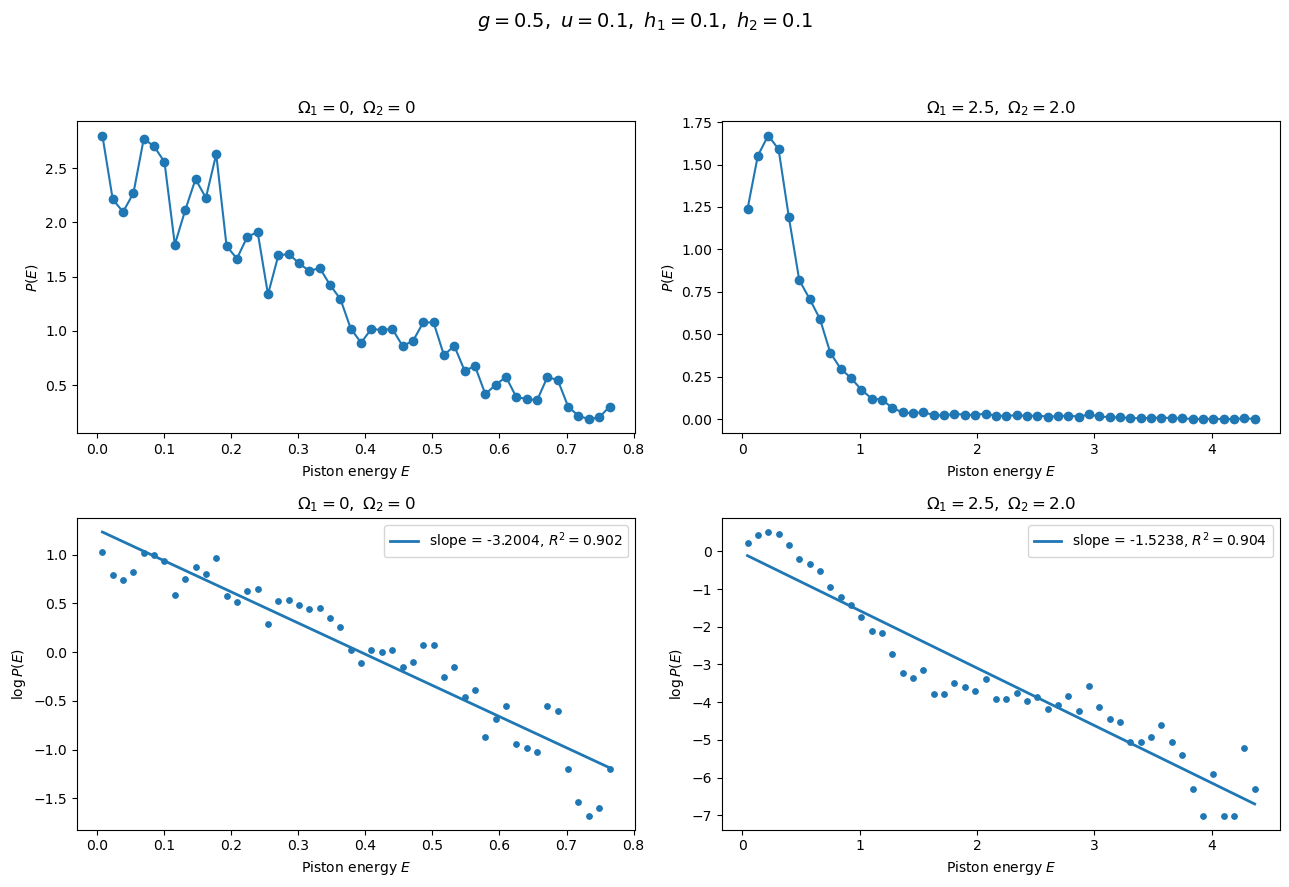

In [ ]:
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt


J = 1.0
h1 = 0.1
h2 = 0.1
g = 0.5
omega_p = 2.5
u = 0.1

frequency_sets = [(0, 0), (2.5, 2.0)]
megno_threshold = 10

n_initial = 100
n_periods = 500
T = 4*np.pi
tlist = np.linspace(0, n_periods*T, n_periods + 1)

rng = np.random.default_rng(12345)

initial_conditions = []

for i in range(n_initial):
    q0 = rng.uniform(-0.90, 0.90)
    p0 = rng.uniform(-0.90, 0.90)
    X0 = rng.uniform(-0.50, 0.50)
    P0 = rng.uniform(-0.50, 0.50)
    initial_conditions.append([q0, p0, X0, P0])

initial_conditions = np.array(initial_conditions)

os.makedirs("megno_data", exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for k, (Omega1, Omega2) in enumerate(frequency_sets):

    print(f"Running Omega1 = {Omega1}, Omega2 = {Omega2}")

    megno_values = megno_dynamics(Omega1, Omega2)

    chaotic_indices = np.where(megno_values > megno_threshold)[0]
    print(f"Number of chaotic ICs: {len(chaotic_indices)}")
    print("Chaotic IC numbers:", chaotic_indices + 1)

    energies = chaotic_energy(Omega1, Omega2, chaotic_indices)
    E_all = energies.ravel()
    E_all = E_all[np.isfinite(E_all)]

    filename = f"MEGNO_Final_IC_2nd_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_h1_{h1}_h2_{h2}_u_{u}.npz"
    filepath = os.path.join("megno_data", filename)
    np.savez(filepath, initial_conditions=initial_conditions, megno_values=megno_values, chaotic_indices=chaotic_indices, chaotic_energies=energies)

     # Energy distribution
    counts, bins = np.histogram(E_all, bins=50, density=True)
    E_centers = 0.5*(bins[:-1] + bins[1:])

    axes[0, k].plot(E_centers, counts, "o-")
    axes[0, k].set_xlabel("Piston energy $E$")
    axes[0, k].set_ylabel("$P(E)$")
    axes[0, k].set_title(rf"$\Omega_1={Omega1},\ \Omega_2={Omega2}$")

    # log P(E)
    mask = counts > 0

    E_fit = E_centers[mask]
    log_P = np.log(counts[mask])

    fit = linregress(E_fit, log_P)

    slope = fit.slope
    intercept = fit.intercept
    R2 = fit.rvalue**2

    axes[1, k].scatter(E_fit, log_P, s=15)

    axes[1, k].plot(E_fit, intercept + slope*E_fit, linewidth=2, label=rf"slope = {slope:.4f}, $R^2={R2:.3f}$")

    axes[1, k].set_xlabel("Piston energy $E$")
    axes[1, k].set_ylabel(r"$\log P(E)$")
    axes[1, k].set_title(rf"$\Omega_1={Omega1},\ \Omega_2={Omega2}$")

    axes[1, k].legend()

    print()
    print(f"Omega1 = {Omega1}, Omega2 = {Omega2}")
    print(f"Number of chaotic ICs = {len(energies)}")
    print(f"Slope = {slope}")
    print(f"R² = {R2}")

    if slope < 0:
        beta = -slope
        T_eff = 1/beta

        print(f"Effective beta = {beta}")
        print(f"Effective temperature = {T_eff}")

fig.suptitle(rf"$g={g},\ u={u},\ h_1={h1},\ h_2={h2}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("megno_data/piston_energy_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


Multiprocessing of the above code and normalization

In [7]:
import numpy as np
from scipy.integrate import solve_ivp

def equations(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    dq = (-J*p*(R2-1) + h1*c1*p*q/A - h2*c2*(A2-p**2)/A - g*P*A/np.sqrt(2) - g*p*D/(np.sqrt(2)*A))
    dp = (J*q*(R2-1) + h1*c1*(A2-q**2)/A - h2*c2*p*q/A - g*X*A/np.sqrt(2) + g*q*D/(np.sqrt(2)*A))
    dX = (omega_p*P - (u/2)*(X**2+P**2)*P - g*p*A/np.sqrt(2))
    dP = (-omega_p*X + (u/2)*(X**2+P**2)*X - g*q*A/np.sqrt(2))

    return np.array([dq, dp, dX, dP])

def jacobian(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    C = D/A

    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    Cq = X/A + D*q/A**3
    Cp = -P/A + D*p/A**3

    J11 = (-2*J*p*q + h1*c1*(p/A + p*q**2/A**3) + h2*c2*(q/A + p**2*q/A**3) + g*P*q/(np.sqrt(2)*A) - g*p*Cq/np.sqrt(2))

    J12 = (-J*(R2-1+2*p**2) + h1*c1*(q/A + p**2*q/A**3) + h2*c2*(3*p/A + p**3/A**3) + g*P*p/(np.sqrt(2)*A) - g*p*Cp/np.sqrt(2) - g*D/(np.sqrt(2)*A))

    J13 = -g*p*q/(np.sqrt(2)*A)
    J14 = -g*A/np.sqrt(2) + g*p**2/(np.sqrt(2)*A)

    J21 = (J*(R2-1+2*q**2) - h1*c1*(3*q/A + q**3/A**3) - h2*c2*(p/A + p*q**2/A**3) + g*X*q/(np.sqrt(2)*A) + g*(C + q*Cq)/np.sqrt(2))

    J22 = (2*J*p*q - h1*c1*(p/A + q**2*p/A**3) - h2*c2*(q/A + p**2*q/A**3) + g*X*p/(np.sqrt(2)*A) + g*q*Cp/np.sqrt(2))

    J23 = -g*A/np.sqrt(2) + g*q**2/(np.sqrt(2)*A)
    J24 = -g*q*p/(np.sqrt(2)*A)

    J31 = g*p*q/(np.sqrt(2)*A)
    J32 = -g*(A - p**2/A)/np.sqrt(2)
    J33 = -u*X*P
    J34 = omega_p - (u/2)*(X**2 + 3*P**2)

    J41 = -g*(A - q**2/A)/np.sqrt(2)
    J42 = g*p*q/(np.sqrt(2)*A)
    J43 = -omega_p + (u/2)*(3*X**2 + P**2)
    J44 = u*X*P

    return np.array([
        [J11, J12, J13, J14],
        [J21, J22, J23, J24],
        [J31, J32, J33, J34],
        [J41, J42, J43, J44]
    ])

def megno_equations(t, Y, Omega1, Omega2):

    y = Y[:4]
    v = Y[4:8]
    Z = Y[8]

    dy = equations(t, y, Omega1, Omega2)
    M = jacobian(t, y, Omega1, Omega2)
    
    dv_raw = M @ v
    W = np.dot(v, dv_raw)

    dv = dv_raw - W*v
    dZ = t*W

    return np.concatenate((dy, dv, [dZ]))

def megno_dynamics(args):
   
    Omega1 = args["Omega1"]
    Omega2 = args["Omega2"]
    ic = args["ic"]
    q0, p0, X0, P0 = ic
    
    v0 = np.array([1.0, 0.0, 0.0, 0.0])
    Y0 = np.concatenate(([q0, p0, X0, P0], v0, [0.0]))

    sol = solve_ivp(megno_equations, (0, n_periods*T), Y0, args=(Omega1, Omega2), method="DOP853", t_eval=tlist, rtol=1e-9, atol=1e-11, max_step=T/20)

    if sol.success:
        X = sol.y[2]
        P = sol.y[3]
        energies = ((omega_p/2)*(X**2 + P**2) - (u/8)*(X**2 + P**2)**2)
        Z = sol.y[8]
        Y_megno = np.zeros_like(sol.t)
        Y_megno[1:] = 2*Z[1:]/sol.t[1:]
        megno_final = Y_megno[-1]
    else:
        v = sol.y[4:8]
        v_norm = np.linalg.norm(v, axis=0)
        q = sol.y[0]
        p = sol.y[1]
        A2 = 2.0 - q**2 - p**2

        print(f"Integration failed at t={sol.t[-1]:.6f}, "
        f"minimum A2={np.min(A2):.6e}, "
        f"minimum |v| = {np.min(v_norm):.6e}, "
        f"maximum |v| = {np.max(v_norm):.6e}, "
        f"message={sol.message}")
        
        energies = np.full(len(tlist), np.nan)
        megno_final = np.nan  # or some other value indicating failure    

    return megno_final , energies


Running Omega1 = 0, Omega2 = 0
Number of chaotic ICs: 9
Chaotic IC numbers: [ 2  9 10 24 29 61 63 94 98]

Slope = -3.227034116143739
R² = 0.8849595966985853
Effective beta = 3.227034116143739
Effective temperature = 0.30988206632131493
---------------------------------
Running Omega1 = 2.5, Omega2 = 2.0
Number of chaotic ICs: 25
Chaotic IC numbers: [ 4  6  9 18 22 24 25 38 40 41 43 45 46 52 57 59 61 62 64 74 85 87 90 96
 98]

Slope = -1.5404122825611166
R² = 0.9493770514842901
Effective beta = 1.5404122825611166
Effective temperature = 0.6491768543531621
---------------------------------


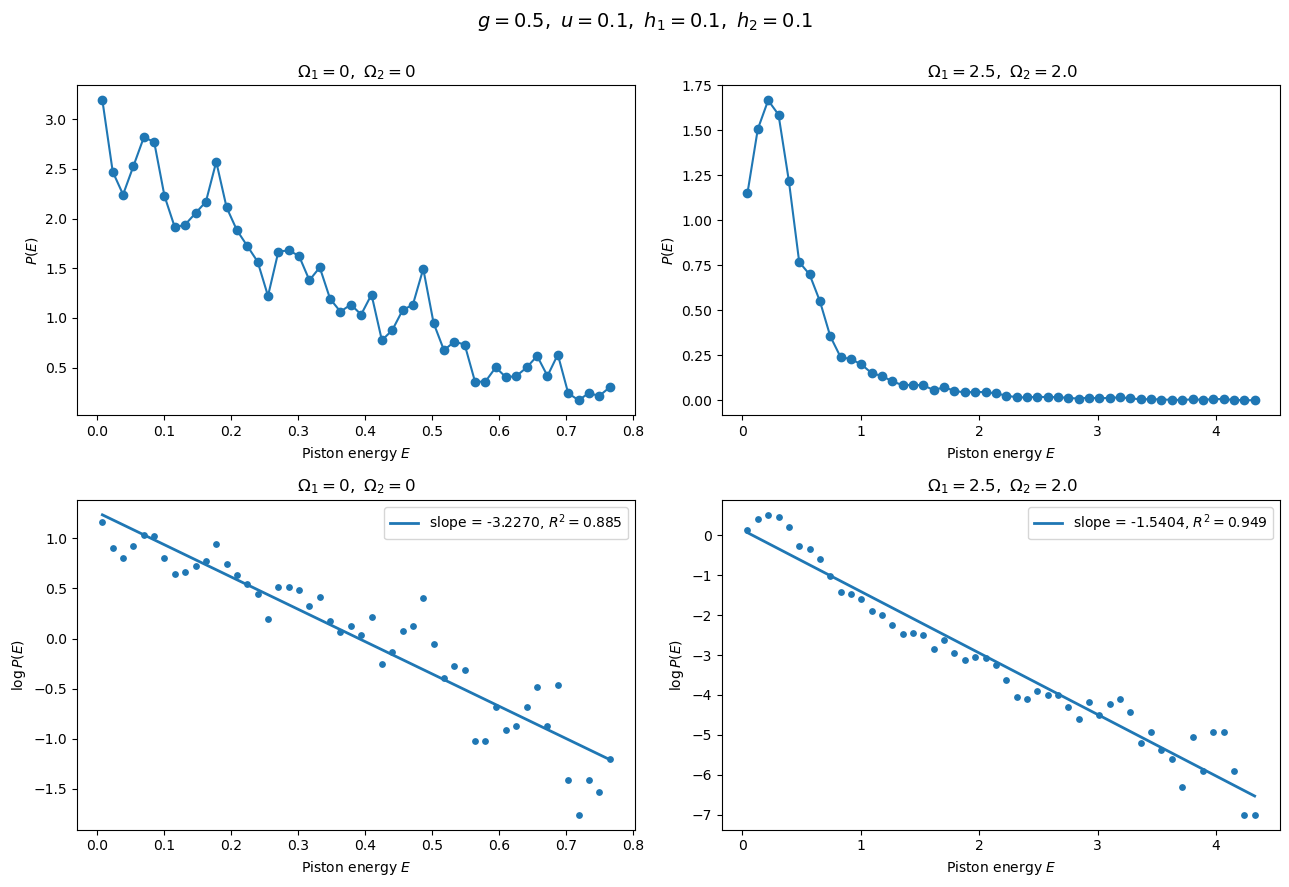

In [9]:
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt
from multiprocessing import Pool

J = 1.0
h1 = 0.1
h2 = 0.1
g = 0.5
omega_p = 2.5
u = 0.1
frequency_sets = [(0, 0), (2.5, 2.0)]
megno_threshold = 10
n_initial = 100
n_periods = 500
T = 4*np.pi
tlist = np.linspace(0, n_periods*T, n_periods + 1)
tlist = np.linspace(0, n_periods*T, n_periods + 1)

rng = np.random.default_rng(12345)

initial_conditions = []

for i in range(n_initial):
    q0 = rng.uniform(-0.90, 0.90)
    p0 = rng.uniform(-0.90, 0.90)
    X0 = rng.uniform(-0.50, 0.50)
    P0 = rng.uniform(-0.50, 0.50)
    initial_conditions.append([q0, p0, X0, P0])

initial_conditions = np.array(initial_conditions)

os.makedirs("megno_data", exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for k, (Omega1, Omega2) in enumerate(frequency_sets):

    args = [{"Omega1": Omega1, "Omega2": Omega2, "ic": ic} for ic in initial_conditions]

    with Pool(processes=4) as pool:
        print(f"Running Omega1 = {Omega1}, Omega2 = {Omega2}")

        results = pool.map(megno_dynamics, args)

        megno_values = np.array([result[0] for result in results])
        energies = np.array([result[1] for result in results])

        # megno_values = results[:, 0]
        # energies = results[:, 1]

        chaotic_indices = np.where(megno_values > megno_threshold)[0]
        print(f"Number of chaotic ICs: {len(chaotic_indices)}")
        print("Chaotic IC numbers:", chaotic_indices + 1)

        chaotic_energies = energies[chaotic_indices]
        E_all = chaotic_energies.ravel()
        E_all = E_all[np.isfinite(E_all)]

    filename = f"MEGNO_Final_IC_2nd_multiprocess_norm_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_h1_{h1}_h2_{h2}_u_{u}.npz"
    filepath = os.path.join("megno_data", filename)
    np.savez(filepath, initial_conditions=initial_conditions, megno_values=megno_values, chaotic_indices=chaotic_indices, chaotic_energies=chaotic_energies)

     # Energy distribution
    counts, bins = np.histogram(E_all, bins=50, density=True)
    E_centers = 0.5*(bins[:-1] + bins[1:])

    axes[0, k].plot(E_centers, counts, "o-")
    axes[0, k].set_xlabel("Piston energy $E$")
    axes[0, k].set_ylabel("$P(E)$")
    axes[0, k].set_title(rf"$\,\Omega_1={Omega1},\ \Omega_2={Omega2}$")

    # log P(E)
    mask = counts > 0

    E_fit = E_centers[mask]
    log_P = np.log(counts[mask])

    fit = linregress(E_fit, log_P)

    slope = fit.slope
    intercept = fit.intercept
    R2 = fit.rvalue**2

    axes[1, k].scatter(E_fit, log_P, s=15)

    axes[1, k].plot(E_fit, intercept + slope*E_fit, linewidth=2, label=rf"slope = {slope:.4f}, $R^2={R2:.3f}$")

    axes[1, k].set_xlabel("Piston energy $E$")
    axes[1, k].set_ylabel(r"$\log P(E)$")
    axes[1, k].set_title(rf"$\,\Omega_1={Omega1},\ \Omega_2={Omega2}$")

    axes[1, k].legend()

    print()
    #print(f"h1 = {h1}, h2 = {h2}")
    #print(f"Number of chaotic ICs = {len(chaotic_energies)}")
    print(f"Slope = {slope}")
    print(f"R² = {R2}")

    if slope < 0:
        beta = -slope
        T_eff = 1/beta

        print(f"Effective beta = {beta}")
        print(f"Effective temperature = {T_eff}")
        print("---------------------------------")

fig.suptitle(rf"$g={g},\ u={u},\ h_1={h1},\ h_2={h2}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("megno_data/piston_energy_distribution_multiprocess_norm.png", dpi=300, bbox_inches="tight")
plt.show()


$h_1 = 1, h_2 = 0.001, \Omega_1 = 0.7, \Omega_2 = 100$ 

$h_1 = 0.001, h_2 = 60.12, \Omega_1 = 0.7, \Omega_2 = 100$

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp

def equations(t, y, h1, h2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    dq = (-J*p*(R2-1) + h1*c1*p*q/A - h2*c2*(A2-p**2)/A - g*P*A/np.sqrt(2) - g*p*D/(np.sqrt(2)*A))
    dp = (J*q*(R2-1) + h1*c1*(A2-q**2)/A - h2*c2*p*q/A - g*X*A/np.sqrt(2) + g*q*D/(np.sqrt(2)*A))
    dX = (omega_p*P - (u/2)*(X**2+P**2)*P - g*p*A/np.sqrt(2))
    dP = (-omega_p*X + (u/2)*(X**2+P**2)*X - g*q*A/np.sqrt(2))

    return np.array([dq, dp, dX, dP])

def jacobian(t, y, h1, h2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    C = D/A

    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    Cq = X/A + D*q/A**3
    Cp = -P/A + D*p/A**3

    J11 = (-2*J*p*q + h1*c1*(p/A + p*q**2/A**3) + h2*c2*(q/A + p**2*q/A**3) + g*P*q/(np.sqrt(2)*A) - g*p*Cq/np.sqrt(2))

    J12 = (-J*(R2-1+2*p**2) + h1*c1*(q/A + p**2*q/A**3) + h2*c2*(3*p/A + p**3/A**3) + g*P*p/(np.sqrt(2)*A) - g*p*Cp/np.sqrt(2) - g*D/(np.sqrt(2)*A))

    J13 = -g*p*q/(np.sqrt(2)*A)
    J14 = -g*A/np.sqrt(2) + g*p**2/(np.sqrt(2)*A)

    J21 = (J*(R2-1+2*q**2) - h1*c1*(3*q/A + q**3/A**3) - h2*c2*(p/A + p*q**2/A**3) + g*X*q/(np.sqrt(2)*A) + g*(C + q*Cq)/np.sqrt(2))

    J22 = (2*J*p*q - h1*c1*(p/A + q**2*p/A**3) - h2*c2*(q/A + p**2*q/A**3) + g*X*p/(np.sqrt(2)*A) + g*q*Cp/np.sqrt(2))

    J23 = -g*A/np.sqrt(2) + g*q**2/(np.sqrt(2)*A)
    J24 = -g*q*p/(np.sqrt(2)*A)

    J31 = g*p*q/(np.sqrt(2)*A)
    J32 = -g*(A - p**2/A)/np.sqrt(2)
    J33 = -u*X*P
    J34 = omega_p - (u/2)*(X**2 + 3*P**2)

    J41 = -g*(A - q**2/A)/np.sqrt(2)
    J42 = g*p*q/(np.sqrt(2)*A)
    J43 = -omega_p + (u/2)*(3*X**2 + P**2)
    J44 = u*X*P

    return np.array([
        [J11, J12, J13, J14],
        [J21, J22, J23, J24],
        [J31, J32, J33, J34],
        [J41, J42, J43, J44]
    ])

def megno_equations(t, Y, h1, h2):

    y = Y[:4]
    delta = Y[4:8]
    Z = Y[8]

    dy = equations(t, y, h1, h2)
    M = jacobian(t, y, h1, h2)
    ddelta = M @ delta
    delta2 = np.dot(delta, delta)
    W = np.dot(delta, ddelta)/delta2
    dZ = t*W

    return np.concatenate((dy, ddelta, [dZ]))

def megno_dynamics(h1, h2):

    megno_values = []

    for i, (q0, p0, X0, P0) in enumerate(initial_conditions):

        delta0 = np.array([1e-6, 0.0, 0.0, 0.0])

        Y0 = np.concatenate(([q0, p0, X0, P0], delta0, [0.0]))

        sol = solve_ivp(megno_equations, (0, n_periods*T), Y0, args=(h1, h2), method="DOP853", t_eval=tlist, rtol=1e-9, atol=1e-11, max_step=0.005)

        #print(i, sol.success, len(sol.t), sol.message)
        # q = sol.y[0]
        # p = sol.y[1]
        # A2 = 2.0 - q**2 - p**2
        # print("minimum A2 =", np.min(A2))
        if sol.success:
            Z = sol.y[8]
            Y_megno = np.zeros_like(sol.t)
            Y_megno[1:] = 2*Z[1:]/sol.t[1:]
            megno_final = Y_megno[-1]
        else:
            megno_final = np.nan  # or some other value indicating failure    

        megno_values.append(megno_final)

        

    return np.array(megno_values)

def chaotic_energy(h1, h2, chaotic_indices):

    energies = []

    for i in chaotic_indices:

        q0, p0, X0, P0 = initial_conditions[i]

        sol = solve_ivp(equations, (0, n_periods*T), [q0, p0, X0, P0], args=(h1, h2), method="DOP853", t_eval=tlist, rtol=1e-9, atol=1e-11, max_step=0.005)

        if sol.success:

            X = sol.y[2]
            P = sol.y[3]

            E = ((omega_p/2)*(X**2 + P**2) - (u/8)*(X**2 + P**2)**2)

        else:

            print(f"Energy integration failed for IC {i+1}: {sol.message}")
            E = np.full(len(tlist), np.nan)

        energies.append(E)

    return np.array(energies)

Running h1 = 1, h2 = 0.001
Number of chaotic ICs: 0
Chaotic IC numbers: []


/home/soumya/anaconda3/envs/work0/lib/python3.8/site-packages/numpy/lib/histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


ValueError: Inputs must not be empty.

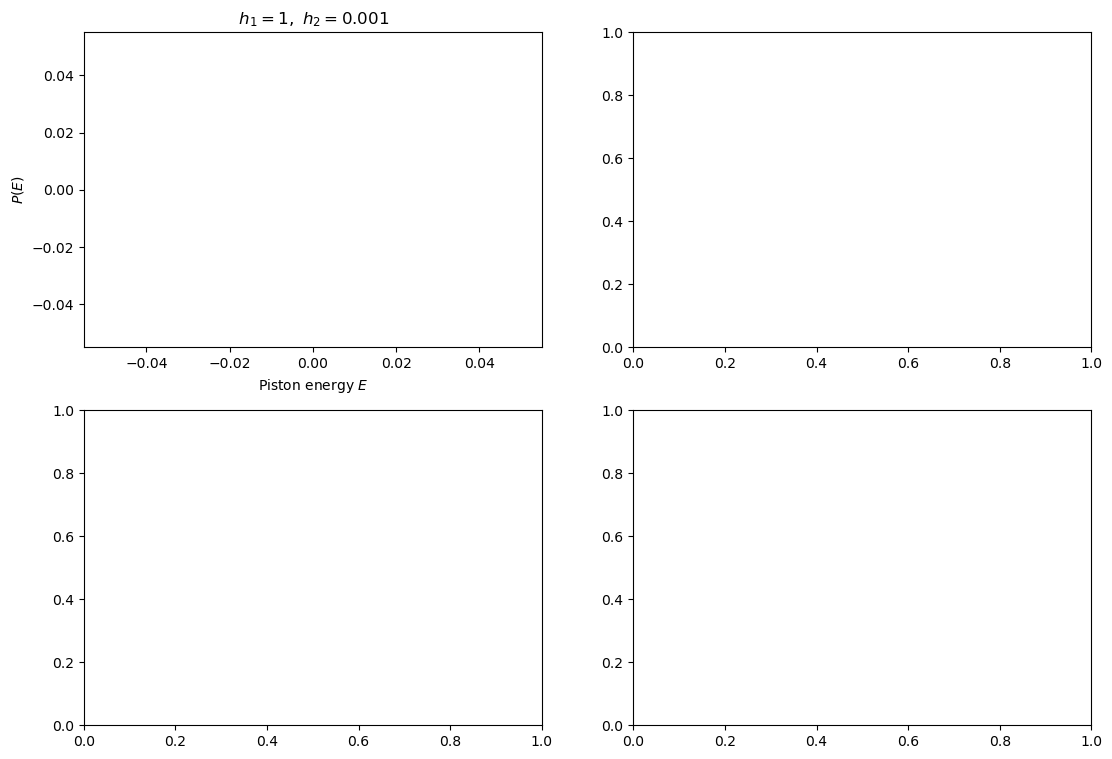

In [ ]:
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt

J = 1.0
Omega1 = 0.7
Omega2 = 100.0
g = 0.5
omega_p = 2.5
u = 0.1

hs = [(1, 0.001), (0.001, 60.12)]
megno_threshold = 10

n_initial = 10
n_periods = 100
T = 20*np.pi
tlist = np.linspace(0, n_periods*T, n_periods + 1)

rng = np.random.default_rng(12345)

initial_conditions = []

for i in range(n_initial):
    q0 = rng.uniform(-0.90, 0.90)
    p0 = rng.uniform(-0.90, 0.90)
    X0 = rng.uniform(-0.50, 0.50)
    P0 = rng.uniform(-0.50, 0.50)
    initial_conditions.append([q0, p0, X0, P0])

initial_conditions = np.array(initial_conditions)

os.makedirs("megno_data", exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for k, (h1, h2) in enumerate(hs):

    print(f"Running h1 = {h1}, h2 = {h2}")

    megno_values = megno_dynamics(Omega1, Omega2)

    chaotic_indices = np.where(megno_values > megno_threshold)[0]
    print(f"Number of chaotic ICs: {len(chaotic_indices)}")
    print("Chaotic IC numbers:", chaotic_indices + 1)

    energies = chaotic_energy(h1, h2, chaotic_indices)
    E_all = energies.ravel()
    E_all = E_all[np.isfinite(E_all)]

    filename = f"MEGNO_Final_IC_2nd_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_h1_{h1}_h2_{h2}_u_{u}.npz"
    filepath = os.path.join("megno_data", filename)
    np.savez(filepath, initial_conditions=initial_conditions, megno_values=megno_values, chaotic_indices=chaotic_indices, chaotic_energies=energies)

     # Energy distribution
    counts, bins = np.histogram(E_all, bins=50, density=True)
    E_centers = 0.5*(bins[:-1] + bins[1:])

    axes[0, k].plot(E_centers, counts, "o-")
    axes[0, k].set_xlabel("Piston energy $E$")
    axes[0, k].set_ylabel("$P(E)$")
    axes[0, k].set_title(rf"$\,h_1={h1},\ h_2={h2}$")

    # log P(E)
    mask = counts > 0

    E_fit = E_centers[mask]
    log_P = np.log(counts[mask])

    fit = linregress(E_fit, log_P)

    slope = fit.slope
    intercept = fit.intercept
    R2 = fit.rvalue**2

    axes[1, k].scatter(E_fit, log_P, s=15)

    axes[1, k].plot(E_fit, intercept + slope*E_fit, linewidth=2, label=rf"slope = {slope:.4f}, $R^2={R2:.3f}$")

    axes[1, k].set_xlabel("Piston energy $E$")
    axes[1, k].set_ylabel(r"$\log P(E)$")
    axes[1, k].set_title(rf"$\,h_1={h1},\ h_2={h2}$")

    axes[1, k].legend()

    print()
    print(f"h1 = {h1}, h2 = {h2}")
    print(f"Number of chaotic ICs = {len(energies)}")
    print(f"Slope = {slope}")
    print(f"R² = {R2}")

    if slope < 0:
        beta = -slope
        T_eff = 1/beta

        print(f"Effective beta = {beta}")
        print(f"Effective temperature = {T_eff}")

fig.suptitle(rf"$g={g},\ u={u},\Omega1={Omega1},\Omega2={Omega2}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(f"megno_data/piston_energy_distribution_Omega1_{Omega1}_Omega2_{Omega2}.png", dpi=300, bbox_inches="tight")
plt.show()


Multiprocessing

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp

def equations(t, y, h1, h2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    dq = (-J*p*(R2-1) + h1*c1*p*q/A - h2*c2*(A2-p**2)/A - g*P*A/np.sqrt(2) - g*p*D/(np.sqrt(2)*A))
    dp = (J*q*(R2-1) + h1*c1*(A2-q**2)/A - h2*c2*p*q/A - g*X*A/np.sqrt(2) + g*q*D/(np.sqrt(2)*A))
    dX = (omega_p*P - (u/2)*(X**2+P**2)*P - g*p*A/np.sqrt(2))
    dP = (-omega_p*X + (u/2)*(X**2+P**2)*X - g*q*A/np.sqrt(2))

    return np.array([dq, dp, dX, dP])

def jacobian(t, y, h1, h2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    C = D/A

    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    Cq = X/A + D*q/A**3
    Cp = -P/A + D*p/A**3

    J11 = (-2*J*p*q + h1*c1*(p/A + p*q**2/A**3) + h2*c2*(q/A + p**2*q/A**3) + g*P*q/(np.sqrt(2)*A) - g*p*Cq/np.sqrt(2))

    J12 = (-J*(R2-1+2*p**2) + h1*c1*(q/A + p**2*q/A**3) + h2*c2*(3*p/A + p**3/A**3) + g*P*p/(np.sqrt(2)*A) - g*p*Cp/np.sqrt(2) - g*D/(np.sqrt(2)*A))

    J13 = -g*p*q/(np.sqrt(2)*A)
    J14 = -g*A/np.sqrt(2) + g*p**2/(np.sqrt(2)*A)

    J21 = (J*(R2-1+2*q**2) - h1*c1*(3*q/A + q**3/A**3) - h2*c2*(p/A + p*q**2/A**3) + g*X*q/(np.sqrt(2)*A) + g*(C + q*Cq)/np.sqrt(2))

    J22 = (2*J*p*q - h1*c1*(p/A + q**2*p/A**3) - h2*c2*(q/A + p**2*q/A**3) + g*X*p/(np.sqrt(2)*A) + g*q*Cp/np.sqrt(2))

    J23 = -g*A/np.sqrt(2) + g*q**2/(np.sqrt(2)*A)
    J24 = -g*q*p/(np.sqrt(2)*A)

    J31 = g*p*q/(np.sqrt(2)*A)
    J32 = -g*(A - p**2/A)/np.sqrt(2)
    J33 = -u*X*P
    J34 = omega_p - (u/2)*(X**2 + 3*P**2)

    J41 = -g*(A - q**2/A)/np.sqrt(2)
    J42 = g*p*q/(np.sqrt(2)*A)
    J43 = -omega_p + (u/2)*(3*X**2 + P**2)
    J44 = u*X*P

    return np.array([
        [J11, J12, J13, J14],
        [J21, J22, J23, J24],
        [J31, J32, J33, J34],
        [J41, J42, J43, J44]
    ])

def megno_equations(t, Y, h1, h2):

    y = Y[:4]
    delta = Y[4:8]
    Z = Y[8]

    dy = equations(t, y, h1, h2)
    M = jacobian(t, y, h1, h2)
    ddelta = M @ delta
    delta2 = np.dot(delta, delta)
    W = np.dot(delta, ddelta)/delta2
    dZ = t*W

    return np.concatenate((dy, ddelta, [dZ]))

def megno_dynamics(args):
   
    h1 = args["h1"]
    h2 = args["h2"]
    ic = args["ic"]
    q0, p0, X0, P0 = ic
    
    delta0 = np.array([1e-6, 0.0, 0.0, 0.0])
    Y0 = np.concatenate(([q0, p0, X0, P0], delta0, [0.0]))

    sol = solve_ivp(megno_equations, (0, n_periods*T), Y0, args=(h1, h2), method="DOP853", t_eval=tlist, rtol=1e-9, atol=1e-11, max_step=0.01)

    if sol.success:
        X = sol.y[2]
        P = sol.y[3]
        energies = ((omega_p/2)*(X**2 + P**2) - (u/8)*(X**2 + P**2)**2)
        Z = sol.y[8]
        Y_megno = np.zeros_like(sol.t)
        Y_megno[1:] = 2*Z[1:]/sol.t[1:]
        megno_final = Y_megno[-1]
    else:
        delta = sol.y[4:8]
        delta_norm = np.linalg.norm(delta, axis=0)
        q = sol.y[0]
        p = sol.y[1]
        A2 = 2.0 - q**2 - p**2

        print(f"Integration failed at t={sol.t[-1]:.6f}, "
        f"minimum A2={np.min(A2):.6e}, "
        f"max |delta|={np.max(delta_norm):.6e}, "
        f"message={sol.message}")
        
        energies = np.full(len(tlist), np.nan)
        megno_final = np.nan  # or some other value indicating failure    

    return megno_final , energies


Running h1 = 1, h2 = 0.001
Integration failed at t=3707.079331, minimum A2=3.009397e-03, max |delta|=1.614669e+152, message=Required step size is less than spacing between numbers.
Integration failed at t=439.822972, minimum A2=4.378779e-01, max |delta|=2.246786e+09, message=Required step size is less than spacing between numbers.
Integration failed at t=4712.388980, minimum A2=5.073017e-03, max |delta|=2.588434e+151, message=Required step size is less than spacing between numbers.
Integration failed at t=2953.097094, minimum A2=3.394071e-03, max |delta|=1.628449e+75, message=Required step size is less than spacing between numbers.
Integration failed at t=3392.920066, minimum A2=7.401040e-03, max |delta|=1.440281e+83, message=Required step size is less than spacing between numbers.
Integration failed at t=5906.194189, minimum A2=7.259380e-02, max |delta|=6.561182e+152, message=Required step size is less than spacing between numbers.
Integration failed at t=0.000000, minimum A2=1.058021

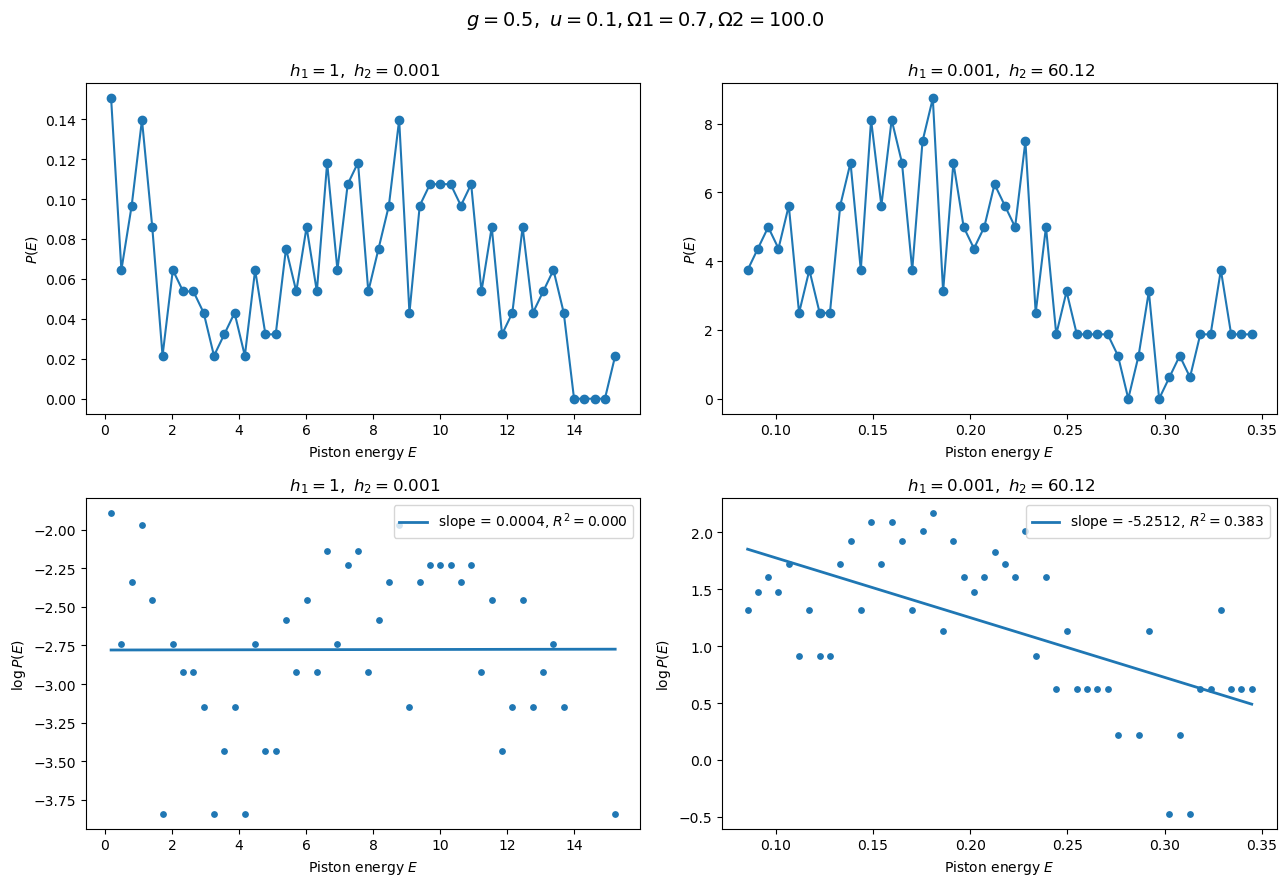

In [ ]:
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt
from multiprocessing import Pool

J = 1.0
Omega1 = 0.7
Omega2 = 100.0
g = 0.5
omega_p = 2.5
u = 0.1

hs = [(1, 0.001), (0.001, 60.12)]
megno_threshold = 2

n_initial = 10
n_periods = 100
T = 20*np.pi
tlist = np.linspace(0, n_periods*T, n_periods + 1)

rng = np.random.default_rng(12345)

initial_conditions = []

for i in range(n_initial):
    q0 = rng.uniform(-0.90, 0.90)
    p0 = rng.uniform(-0.90, 0.90)
    X0 = rng.uniform(-0.50, 0.50)
    P0 = rng.uniform(-0.50, 0.50)
    initial_conditions.append([q0, p0, X0, P0])

initial_conditions = np.array(initial_conditions)

os.makedirs("megno_data", exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for k, (h1, h2) in enumerate(hs):

    args = [{"h1": h1, "h2": h2, "ic": ic} for ic in initial_conditions]

    with Pool(processes=4) as pool:

        print(f"Running h1 = {h1}, h2 = {h2}")
        results = pool.map(megno_dynamics, args)
        megno_values = np.array([result[0] for result in results])
        energies = np.array([result[1] for result in results])

        chaotic_indices = np.where(megno_values > megno_threshold)[0]
        print(f"Number of chaotic ICs: {len(chaotic_indices)}")
        print("Chaotic IC numbers:", chaotic_indices + 1)

        chaotic_energies = energies[chaotic_indices]
        E_all = chaotic_energies.ravel()
        E_all = E_all[np.isfinite(E_all)]

    filename = f"MEGNO_Final_IC_2nd_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_h1_{h1}_h2_{h2}_u_{u}.npz"
    filepath = os.path.join("megno_data", filename)
    np.savez(filepath, initial_conditions=initial_conditions, megno_values=megno_values, chaotic_indices=chaotic_indices, chaotic_energies=chaotic_energies)

     # Energy distribution
    counts, bins = np.histogram(E_all, bins=50, density=True)
    E_centers = 0.5*(bins[:-1] + bins[1:])

    axes[0, k].plot(E_centers, counts, "o-")
    axes[0, k].set_xlabel("Piston energy $E$")
    axes[0, k].set_ylabel("$P(E)$")
    axes[0, k].set_title(rf"$\,h_1={h1},\ h_2={h2}$")

    # log P(E)
    mask = counts > 0

    E_fit = E_centers[mask]
    log_P = np.log(counts[mask])

    fit = linregress(E_fit, log_P)

    slope = fit.slope
    intercept = fit.intercept
    R2 = fit.rvalue**2

    axes[1, k].scatter(E_fit, log_P, s=15)

    axes[1, k].plot(E_fit, intercept + slope*E_fit, linewidth=2, label=rf"slope = {slope:.4f}, $R^2={R2:.3f}$")

    axes[1, k].set_xlabel("Piston energy $E$")
    axes[1, k].set_ylabel(r"$\log P(E)$")
    axes[1, k].set_title(rf"$\,h_1={h1},\ h_2={h2}$")

    axes[1, k].legend()

    print()
    print(f"h1 = {h1}, h2 = {h2}")
    print(f"Number of chaotic ICs = {len(chaotic_energies)}")
    print(f"Slope = {slope}")
    print(f"R² = {R2}")

    if slope < 0:
        beta = -slope
        T_eff = 1/beta

        print(f"Effective beta = {beta}")
        print(f"Effective temperature = {T_eff}")

fig.suptitle(rf"$g={g},\ u={u},\Omega1={Omega1},\Omega2={Omega2}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(f"megno_data/piston_energy_distribution_Omega1_{Omega1}_Omega2_{Omega2}.png", dpi=300, bbox_inches="tight")
plt.show()


Megno with Normalization tangent vector (v): $$\delta = |{\delta}|v$$

In [1]:
import numpy as np
from scipy.integrate import solve_ivp

def equations(t, y, h1, h2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    dq = (-J*p*(R2-1) + h1*c1*p*q/A - h2*c2*(A2-p**2)/A - g*P*A/np.sqrt(2) - g*p*D/(np.sqrt(2)*A))
    dp = (J*q*(R2-1) + h1*c1*(A2-q**2)/A - h2*c2*p*q/A - g*X*A/np.sqrt(2) + g*q*D/(np.sqrt(2)*A))
    dX = (omega_p*P - (u/2)*(X**2+P**2)*P - g*p*A/np.sqrt(2))
    dP = (-omega_p*X + (u/2)*(X**2+P**2)*X - g*q*A/np.sqrt(2))

    return np.array([dq, dp, dX, dP])

def jacobian(t, y, h1, h2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    C = D/A

    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    Cq = X/A + D*q/A**3
    Cp = -P/A + D*p/A**3

    J11 = (-2*J*p*q + h1*c1*(p/A + p*q**2/A**3) + h2*c2*(q/A + p**2*q/A**3) + g*P*q/(np.sqrt(2)*A) - g*p*Cq/np.sqrt(2))

    J12 = (-J*(R2-1+2*p**2) + h1*c1*(q/A + p**2*q/A**3) + h2*c2*(3*p/A + p**3/A**3) + g*P*p/(np.sqrt(2)*A) - g*p*Cp/np.sqrt(2) - g*D/(np.sqrt(2)*A))

    J13 = -g*p*q/(np.sqrt(2)*A)
    J14 = -g*A/np.sqrt(2) + g*p**2/(np.sqrt(2)*A)

    J21 = (J*(R2-1+2*q**2) - h1*c1*(3*q/A + q**3/A**3) - h2*c2*(p/A + p*q**2/A**3) + g*X*q/(np.sqrt(2)*A) + g*(C + q*Cq)/np.sqrt(2))

    J22 = (2*J*p*q - h1*c1*(p/A + q**2*p/A**3) - h2*c2*(q/A + p**2*q/A**3) + g*X*p/(np.sqrt(2)*A) + g*q*Cp/np.sqrt(2))

    J23 = -g*A/np.sqrt(2) + g*q**2/(np.sqrt(2)*A)
    J24 = -g*q*p/(np.sqrt(2)*A)

    J31 = g*p*q/(np.sqrt(2)*A)
    J32 = -g*(A - p**2/A)/np.sqrt(2)
    J33 = -u*X*P
    J34 = omega_p - (u/2)*(X**2 + 3*P**2)

    J41 = -g*(A - q**2/A)/np.sqrt(2)
    J42 = g*p*q/(np.sqrt(2)*A)
    J43 = -omega_p + (u/2)*(3*X**2 + P**2)
    J44 = u*X*P

    return np.array([
        [J11, J12, J13, J14],
        [J21, J22, J23, J24],
        [J31, J32, J33, J34],
        [J41, J42, J43, J44]
    ])

def megno_equations(t, Y, h1, h2):

    y = Y[:4]
    v = Y[4:8]
    Z = Y[8]

    dy = equations(t, y, h1, h2)
    M = jacobian(t, y, h1, h2)
    
    dv_raw = M @ v
    W = np.dot(v, dv_raw)

    dv = dv_raw - W*v
    dZ = t*W

    return np.concatenate((dy, dv, [dZ]))

def megno_dynamics(args):
   
    h1 = args["h1"]
    h2 = args["h2"]
    ic = args["ic"]
    q0, p0, X0, P0 = ic
    
    v0 = np.array([1.0, 0.0, 0.0, 0.0])
    Y0 = np.concatenate(([q0, p0, X0, P0], v0, [0.0]))

    sol = solve_ivp(megno_equations, (0, n_periods*T), Y0, args=(h1, h2), method="DOP853", t_eval=tlist, rtol=1e-9, atol=1e-11, max_step=0.01)

    if sol.success:
        X = sol.y[2]
        P = sol.y[3]
        energies = ((omega_p/2)*(X**2 + P**2) - (u/8)*(X**2 + P**2)**2)
        Z = sol.y[8]
        Y_megno = np.zeros_like(sol.t)
        Y_megno[1:] = 2*Z[1:]/sol.t[1:]
        megno_final = Y_megno[-1]
    else:
        v = sol.y[4:8]
        v_norm = np.linalg.norm(v, axis=0)
        q = sol.y[0]
        p = sol.y[1]
        A2 = 2.0 - q**2 - p**2

        print(f"Integration failed at t={sol.t[-1]:.6f}, "
        f"minimum A2={np.min(A2):.6e}, "
        f"minimum |v| = {np.min(v_norm):.6e}, "
        f"maximum |v| = {np.max(v_norm):.6e}, "
        f"message={sol.message}")
        
        energies = np.full(len(tlist), np.nan)
        megno_final = np.nan  # or some other value indicating failure    

    return megno_final , energies


Running h1 = 1, h2 = 0.001
Integration failed at t=0.000000, minimum A2=1.058021e+00, minimum |v| = 1.000000e+00, maximum |v| = 1.000000e+00, message=Required step size is less than spacing between numbers.
Integration failed at t=5340.707511, minimum A2=4.852832e-03, minimum |v| = 1.000000e+00, maximum |v| = 1.000000e+00, message=Required step size is less than spacing between numbers.
Integration failed at t=5215.043805, minimum A2=4.152501e-03, minimum |v| = 1.000000e+00, maximum |v| = 1.000000e+00, message=Required step size is less than spacing between numbers.
Number of chaotic ICs: 7
Chaotic IC numbers: [1 2 3 4 5 7 9]

h1 = 1, h2 = 0.001
Number of chaotic ICs = 7
Slope = -0.13826791045955902
R² = 0.7387153287351458
Effective beta = 0.13826791045955902
Effective temperature = 7.232336097915378
Running h1 = 0.001, h2 = 60.12
Integration failed at t=376.991118, minimum A2=3.155824e-01, minimum |v| = 9.999974e-01, maximum |v| = 1.000000e+00, message=Required step size is less than 

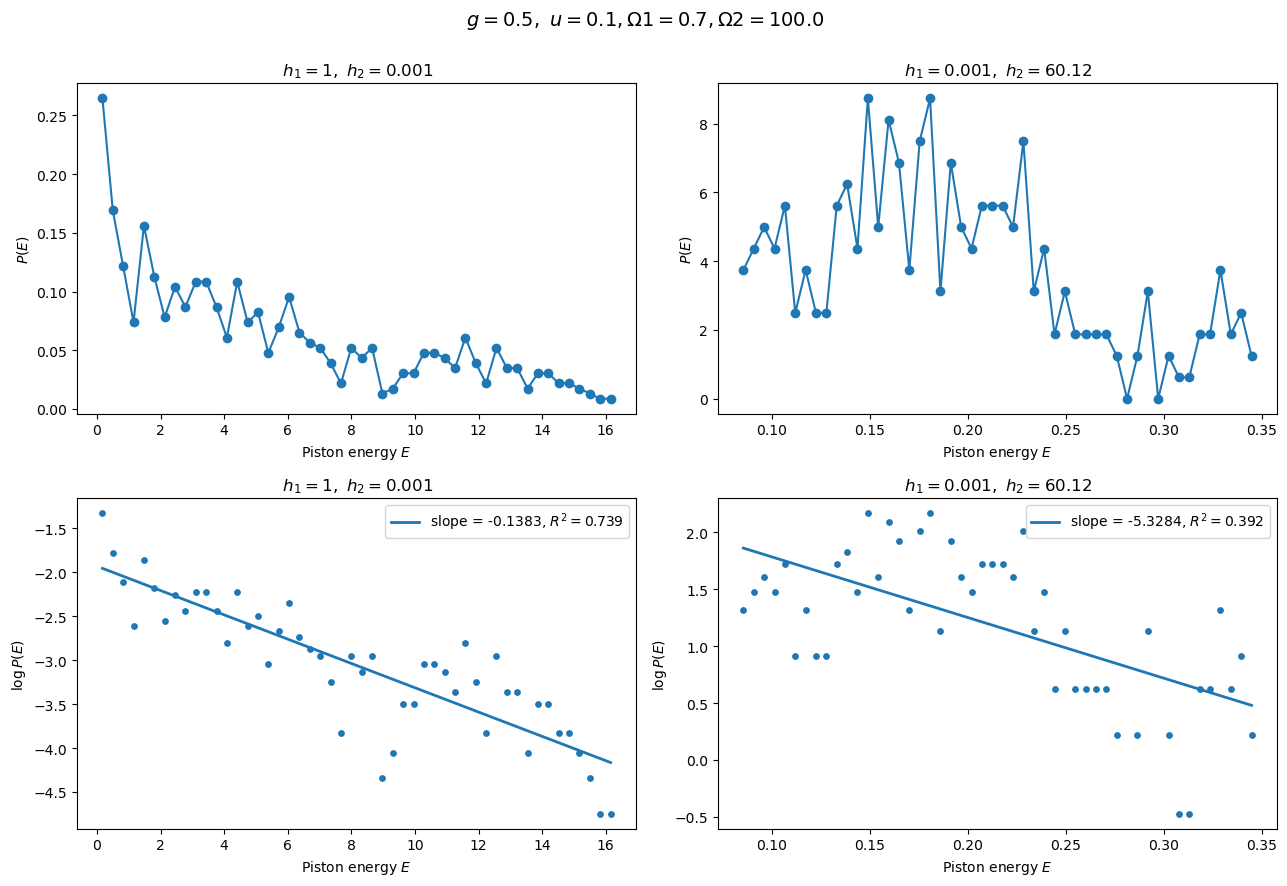

In [ ]:
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt
from multiprocessing import Pool

J = 1.0
Omega1 = 0.7
Omega2 = 100.0
g = 0.5
omega_p = 2.5
u = 0.1

hs = [(1, 0.001), (0.001, 60.12)]
megno_threshold = 2

n_initial = 10
n_periods = 100
T = 20*np.pi
tlist = np.linspace(0, n_periods*T, n_periods + 1)

rng = np.random.default_rng(12345)

initial_conditions = []

for i in range(n_initial):
    q0 = rng.uniform(-0.90, 0.90)
    p0 = rng.uniform(-0.90, 0.90)
    X0 = rng.uniform(-0.50, 0.50)
    P0 = rng.uniform(-0.50, 0.50)
    initial_conditions.append([q0, p0, X0, P0])

initial_conditions = np.array(initial_conditions)

os.makedirs("megno_data", exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for k, (h1, h2) in enumerate(hs):

    args = [{"h1": h1, "h2": h2, "ic": ic} for ic in initial_conditions]

    with Pool(processes=4) as pool:

        print(f"Running h1 = {h1}, h2 = {h2}")
        results = pool.map(megno_dynamics, args)
        megno_values = np.array([result[0] for result in results])
        energies = np.array([result[1] for result in results])

        chaotic_indices = np.where(megno_values > megno_threshold)[0]
        print(f"Number of chaotic ICs: {len(chaotic_indices)}")
        print("Chaotic IC numbers:", chaotic_indices + 1)

        chaotic_energies = energies[chaotic_indices]
        E_all = chaotic_energies.ravel()
        E_all = E_all[np.isfinite(E_all)]

    filename = f"MEGNO_Final_IC_2nd_normalized_tangent_vector_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_h1_{h1}_h2_{h2}_u_{u}.npz"
    filepath = os.path.join("megno_data", filename)
    np.savez(filepath, initial_conditions=initial_conditions, megno_values=megno_values, chaotic_indices=chaotic_indices, chaotic_energies=chaotic_energies)

     # Energy distribution
    counts, bins = np.histogram(E_all, bins=50, density=True)
    E_centers = 0.5*(bins[:-1] + bins[1:])

    axes[0, k].plot(E_centers, counts, "o-")
    axes[0, k].set_xlabel("Piston energy $E$")
    axes[0, k].set_ylabel("$P(E)$")
    axes[0, k].set_title(rf"$\,h_1={h1},\ h_2={h2}$")

    # log P(E)
    mask = counts > 0

    E_fit = E_centers[mask]
    log_P = np.log(counts[mask])

    fit = linregress(E_fit, log_P)

    slope = fit.slope
    intercept = fit.intercept
    R2 = fit.rvalue**2

    axes[1, k].scatter(E_fit, log_P, s=15)

    axes[1, k].plot(E_fit, intercept + slope*E_fit, linewidth=2, label=rf"slope = {slope:.4f}, $R^2={R2:.3f}$")

    axes[1, k].set_xlabel("Piston energy $E$")
    axes[1, k].set_ylabel(r"$\log P(E)$")
    axes[1, k].set_title(rf"$\,h_1={h1},\ h_2={h2}$")

    axes[1, k].legend()

    print()
    #print(f"h1 = {h1}, h2 = {h2}")
    #print(f"Number of chaotic ICs = {len(chaotic_energies)}")
    print(f"Slope = {slope}")
    print(f"R² = {R2}")

    if slope < 0:
        beta = -slope
        T_eff = 1/beta

        print(f"Effective beta = {beta}")
        print(f"Effective temperature = {T_eff}")
        print(-----------------------------------)

fig.suptitle(rf"$g={g},\ u={u},\Omega1={Omega1},\Omega2={Omega2}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(f"megno_data/piston_energy_distribution_normalized_tangent_vector_Omega1_{Omega1}_Omega2_{Omega2}.png", dpi=300, bbox_inches="tight")
plt.show()


Same code as above with different rtol and atol

In [18]:
import numpy as np
from scipy.integrate import solve_ivp

def equations(t, y, h1, h2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    dq = (-J*p*(R2-1) + h1*c1*p*q/A - h2*c2*(A2-p**2)/A - g*P*A/np.sqrt(2) - g*p*D/(np.sqrt(2)*A))
    dp = (J*q*(R2-1) + h1*c1*(A2-q**2)/A - h2*c2*p*q/A - g*X*A/np.sqrt(2) + g*q*D/(np.sqrt(2)*A))
    dX = (omega_p*P - (u/2)*(X**2+P**2)*P - g*p*A/np.sqrt(2))
    dP = (-omega_p*X + (u/2)*(X**2+P**2)*X - g*q*A/np.sqrt(2))

    return np.array([dq, dp, dX, dP])

def jacobian(t, y, h1, h2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    C = D/A

    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    Cq = X/A + D*q/A**3
    Cp = -P/A + D*p/A**3

    J11 = (-2*J*p*q + h1*c1*(p/A + p*q**2/A**3) + h2*c2*(q/A + p**2*q/A**3) + g*P*q/(np.sqrt(2)*A) - g*p*Cq/np.sqrt(2))

    J12 = (-J*(R2-1+2*p**2) + h1*c1*(q/A + p**2*q/A**3) + h2*c2*(3*p/A + p**3/A**3) + g*P*p/(np.sqrt(2)*A) - g*p*Cp/np.sqrt(2) - g*D/(np.sqrt(2)*A))

    J13 = -g*p*q/(np.sqrt(2)*A)
    J14 = -g*A/np.sqrt(2) + g*p**2/(np.sqrt(2)*A)

    J21 = (J*(R2-1+2*q**2) - h1*c1*(3*q/A + q**3/A**3) - h2*c2*(p/A + p*q**2/A**3) + g*X*q/(np.sqrt(2)*A) + g*(C + q*Cq)/np.sqrt(2))

    J22 = (2*J*p*q - h1*c1*(p/A + q**2*p/A**3) - h2*c2*(q/A + p**2*q/A**3) + g*X*p/(np.sqrt(2)*A) + g*q*Cp/np.sqrt(2))

    J23 = -g*A/np.sqrt(2) + g*q**2/(np.sqrt(2)*A)
    J24 = -g*q*p/(np.sqrt(2)*A)

    J31 = g*p*q/(np.sqrt(2)*A)
    J32 = -g*(A - p**2/A)/np.sqrt(2)
    J33 = -u*X*P
    J34 = omega_p - (u/2)*(X**2 + 3*P**2)

    J41 = -g*(A - q**2/A)/np.sqrt(2)
    J42 = g*p*q/(np.sqrt(2)*A)
    J43 = -omega_p + (u/2)*(3*X**2 + P**2)
    J44 = u*X*P

    return np.array([
        [J11, J12, J13, J14],
        [J21, J22, J23, J24],
        [J31, J32, J33, J34],
        [J41, J42, J43, J44]
    ])

def megno_equations(t, Y, h1, h2):

    y = Y[:4]
    v = Y[4:8]
    Z = Y[8]

    dy = equations(t, y, h1, h2)
    M = jacobian(t, y, h1, h2)
    
    dv_raw = M @ v
    W = np.dot(v, dv_raw)

    dv = dv_raw - W*v
    dZ = t*W

    return np.concatenate((dy, dv, [dZ]))

def megno_dynamics(args):
   
    h1 = args["h1"]
    h2 = args["h2"]
    i = args["i"]
    ic = args["ic"]
    q0, p0, X0, P0 = ic
    
    v0 = np.array([1.0, 0.0, 0.0, 0.0])
    Y0 = np.concatenate(([q0, p0, X0, P0], v0, [0.0]))

    sol = solve_ivp(megno_equations, (0, n_periods*T), Y0, args=(h1, h2), method="DOP853", t_eval=tlist, rtol=1e-9, atol=1e-11, max_step=0.01)

    if sol.success:
        X = sol.y[2]
        P = sol.y[3]
        energies = ((omega_p/2)*(X**2 + P**2) - (u/8)*(X**2 + P**2)**2)
        Z = sol.y[8]
        Y_megno = np.zeros_like(sol.t)
        Y_megno[1:] = 2*Z[1:]/sol.t[1:]
        megno_final = Y_megno[-1]
    else:
        v = sol.y[4:8]
        v_norm = np.linalg.norm(v, axis=0)
        q = sol.y[0]
        p = sol.y[1]
        A2 = 2.0 - q**2 - p**2

        print(f"Integration failed at t={sol.t[-1]:.6f}, "
        f"minimum A2={np.min(A2):.6e}, "
        f"minimum |v| = {np.min(v_norm):.6e}, "
        f"maximum |v| = {np.max(v_norm):.6e}, "
        f"message={sol.message}")
        
        energies = np.full(len(tlist), np.nan)
        megno_final = np.nan  # or some other value indicating failure    

    return megno_final , energies, i, sol.success


Running h1 = 1, h2 = 0.001
Integration failed at t=0.000000, minimum A2=1.058021e+00, minimum |v| = 1.000000e+00, maximum |v| = 1.000000e+00, message=Required step size is less than spacing between numbers.
Integration failed at t=5340.707511, minimum A2=4.852832e-03, minimum |v| = 1.000000e+00, maximum |v| = 1.000000e+00, message=Required step size is less than spacing between numbers.
Integration failed at t=5215.043805, minimum A2=4.152501e-03, minimum |v| = 1.000000e+00, maximum |v| = 1.000000e+00, message=Required step size is less than spacing between numbers.
Failed IC numbers: [ 6  8 10]
Number of chaotic ICs: 7
Chaotic IC numbers: [1 2 3 4 5 7 9]

Slope = -0.13826791045955902
R² = 0.7387153287351458
Effective beta = 0.13826791045955902
Effective temperature = 7.232336097915378
---------------------------------
Running h1 = 0.001, h2 = 60.12
Integration failed at t=376.991118, minimum A2=3.155824e-01, minimum |v| = 9.999974e-01, maximum |v| = 1.000000e+00, message=Required step

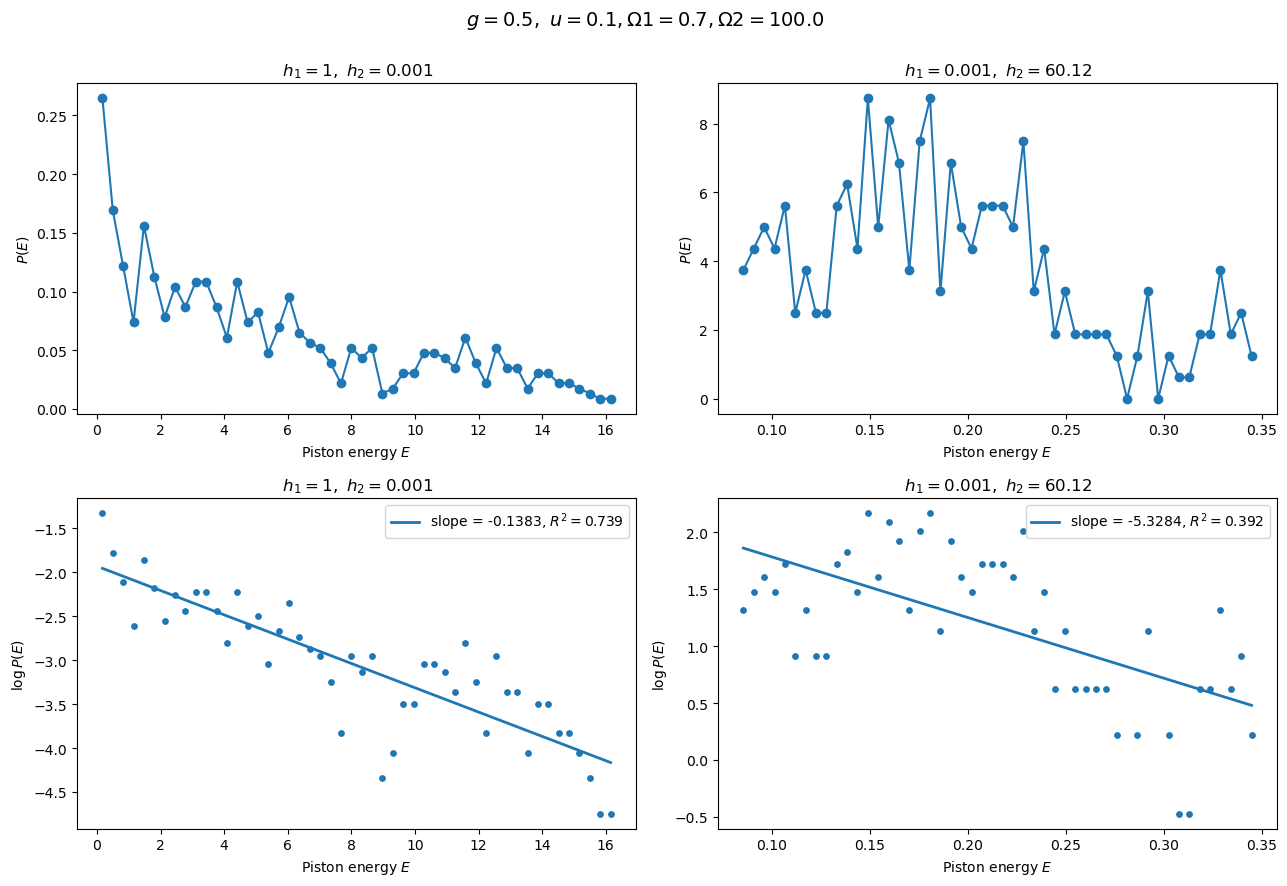

In [19]:
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt
from multiprocessing import Pool

J = 1.0
Omega1 = 0.7
Omega2 = 100.0
g = 0.5
omega_p = 2.5
u = 0.1

hs = [(1, 0.001), (0.001, 60.12)]
megno_threshold = 2

n_initial = 10
n_periods = 100
T = 20*np.pi
tlist = np.linspace(0, n_periods*T, n_periods + 1)

rng = np.random.default_rng(12345)

initial_conditions = []

for i in range(n_initial):
    q0 = rng.uniform(-0.90, 0.90)
    p0 = rng.uniform(-0.90, 0.90)
    X0 = rng.uniform(-0.50, 0.50)
    P0 = rng.uniform(-0.50, 0.50)
    initial_conditions.append([q0, p0, X0, P0])

initial_conditions = np.array(initial_conditions)

os.makedirs("megno_data", exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for k, (h1, h2) in enumerate(hs):

    args = [{"h1": h1, "h2": h2, "i":i, "ic": ic} for i, ic in enumerate(initial_conditions)]

    with Pool(processes=4) as pool:

        print(f"Running h1 = {h1}, h2 = {h2}")
        results = pool.map(megno_dynamics, args)
        megno_values = np.array([result[0] for result in results])
        energies = np.array([result[1] for result in results])

        failed_indices = [result[2] for result in results if not result[3]]
        print("Failed IC numbers:", np.array(failed_indices)+1)

        chaotic_indices = np.where(megno_values > megno_threshold)[0]
        print(f"Number of chaotic ICs: {len(chaotic_indices)}")
        print("Chaotic IC numbers:", chaotic_indices + 1)

        chaotic_energies = energies[chaotic_indices]
        E_all = chaotic_energies.ravel()
        E_all = E_all[np.isfinite(E_all)]

    filename = f"MEGNO_Final_IC_2nd_failed_ic_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_h1_{h1}_h2_{h2}_u_{u}.npz"
    filepath = os.path.join("megno_data", filename)
    np.savez(filepath, initial_conditions=initial_conditions, failed_indices=failed_indices, megno_values=megno_values, chaotic_indices=chaotic_indices, chaotic_energies=chaotic_energies)

     # Energy distribution
    counts, bins = np.histogram(E_all, bins=50, density=True)
    E_centers = 0.5*(bins[:-1] + bins[1:])

    axes[0, k].plot(E_centers, counts, "o-")
    axes[0, k].set_xlabel("Piston energy $E$")
    axes[0, k].set_ylabel("$P(E)$")
    axes[0, k].set_title(rf"$\,h_1={h1},\ h_2={h2}$")

    # log P(E)
    mask = counts > 0

    E_fit = E_centers[mask]
    log_P = np.log(counts[mask])

    fit = linregress(E_fit, log_P)

    slope = fit.slope
    intercept = fit.intercept
    R2 = fit.rvalue**2

    axes[1, k].scatter(E_fit, log_P, s=15)

    axes[1, k].plot(E_fit, intercept + slope*E_fit, linewidth=2, label=rf"slope = {slope:.4f}, $R^2={R2:.3f}$")

    axes[1, k].set_xlabel("Piston energy $E$")
    axes[1, k].set_ylabel(r"$\log P(E)$")
    axes[1, k].set_title(rf"$\,h_1={h1},\ h_2={h2}$")

    axes[1, k].legend()

    print()
    #print(f"h1 = {h1}, h2 = {h2}")
    #print(f"Number of chaotic ICs = {len(chaotic_energies)}")
    print(f"Slope = {slope}")
    print(f"R² = {R2}")

    if slope < 0:
        beta = -slope
        T_eff = 1/beta

        print(f"Effective beta = {beta}")
        print(f"Effective temperature = {T_eff}")
        print("---------------------------------")

fig.suptitle(rf"$g={g},\ u={u},\Omega1={Omega1},\Omega2={Omega2}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
#plt.savefig(f"megno_data/piston_energy_distribution_normalized_tangent_vector_Omega1_{Omega1}_Omega2_{Omega2}.png", dpi=300, bbox_inches="tight")
plt.show()


Simulation for only Failed Initial Conditions

In [24]:
import numpy as np
from scipy.integrate import solve_ivp

def equations(t, y, h1, h2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    dq = (-J*p*(R2-1) + h1*c1*p*q/A - h2*c2*(A2-p**2)/A - g*P*A/np.sqrt(2) - g*p*D/(np.sqrt(2)*A))
    dp = (J*q*(R2-1) + h1*c1*(A2-q**2)/A - h2*c2*p*q/A - g*X*A/np.sqrt(2) + g*q*D/(np.sqrt(2)*A))
    dX = (omega_p*P - (u/2)*(X**2+P**2)*P - g*p*A/np.sqrt(2))
    dP = (-omega_p*X + (u/2)*(X**2+P**2)*X - g*q*A/np.sqrt(2))

    return np.array([dq, dp, dX, dP])

def jacobian(t, y, h1, h2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    C = D/A

    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    Cq = X/A + D*q/A**3
    Cp = -P/A + D*p/A**3

    J11 = (-2*J*p*q + h1*c1*(p/A + p*q**2/A**3) + h2*c2*(q/A + p**2*q/A**3) + g*P*q/(np.sqrt(2)*A) - g*p*Cq/np.sqrt(2))

    J12 = (-J*(R2-1+2*p**2) + h1*c1*(q/A + p**2*q/A**3) + h2*c2*(3*p/A + p**3/A**3) + g*P*p/(np.sqrt(2)*A) - g*p*Cp/np.sqrt(2) - g*D/(np.sqrt(2)*A))

    J13 = -g*p*q/(np.sqrt(2)*A)
    J14 = -g*A/np.sqrt(2) + g*p**2/(np.sqrt(2)*A)

    J21 = (J*(R2-1+2*q**2) - h1*c1*(3*q/A + q**3/A**3) - h2*c2*(p/A + p*q**2/A**3) + g*X*q/(np.sqrt(2)*A) + g*(C + q*Cq)/np.sqrt(2))

    J22 = (2*J*p*q - h1*c1*(p/A + q**2*p/A**3) - h2*c2*(q/A + p**2*q/A**3) + g*X*p/(np.sqrt(2)*A) + g*q*Cp/np.sqrt(2))

    J23 = -g*A/np.sqrt(2) + g*q**2/(np.sqrt(2)*A)
    J24 = -g*q*p/(np.sqrt(2)*A)

    J31 = g*p*q/(np.sqrt(2)*A)
    J32 = -g*(A - p**2/A)/np.sqrt(2)
    J33 = -u*X*P
    J34 = omega_p - (u/2)*(X**2 + 3*P**2)

    J41 = -g*(A - q**2/A)/np.sqrt(2)
    J42 = g*p*q/(np.sqrt(2)*A)
    J43 = -omega_p + (u/2)*(3*X**2 + P**2)
    J44 = u*X*P

    return np.array([
        [J11, J12, J13, J14],
        [J21, J22, J23, J24],
        [J31, J32, J33, J34],
        [J41, J42, J43, J44]
    ])

def megno_equations(t, Y, h1, h2):

    y = Y[:4]
    v = Y[4:8]
    Z = Y[8]

    dy = equations(t, y, h1, h2)
    M = jacobian(t, y, h1, h2)
    
    dv_raw = M @ v
    W = np.dot(v, dv_raw)

    dv = dv_raw - W*v
    dZ = t*W

    return np.concatenate((dy, dv, [dZ]))

def megno_dynamics(args):
   
    h1 = args["h1"]
    h2 = args["h2"]
    i = args["i"]
    f_ic = args["f_ic"]
    q0, p0, X0, P0 = f_ic
    
    v0 = np.array([1.0, 0.0, 0.0, 0.0])
    Y0 = np.concatenate(([q0, p0, X0, P0], v0, [0.0]))

    sol = solve_ivp(megno_equations, (0, n_periods*T), Y0, args=(h1, h2), method="DOP853", t_eval=tlist, rtol=1e-8, atol=1e-10, max_step=0.0001)

    if sol.success:
        X = sol.y[2]
        P = sol.y[3]
        energies = ((omega_p/2)*(X**2 + P**2) - (u/8)*(X**2 + P**2)**2)
        Z = sol.y[8]
        Y_megno = np.zeros_like(sol.t)
        Y_megno[1:] = 2*Z[1:]/sol.t[1:]
        megno_final = Y_megno[-1]
        print(f"Integration succesfull for Failed IC number[i]")
    else:
        v = sol.y[4:8]
        v_norm = np.linalg.norm(v, axis=0)
        q = sol.y[0]
        p = sol.y[1]
        A2 = 2.0 - q**2 - p**2

        print(f"Integration failed at t={sol.t[-1]:.6f}, "
        f"minimum A2={np.min(A2):.6e}, "
        f"minimum |v| = {np.min(v_norm):.6e}, "
        f"maximum |v| = {np.max(v_norm):.6e}, "
        f"message={sol.message}")
        print(f"Failed IC number: {i+1}, Initial conditions: {f_ic}")
        
        energies = np.full(len(tlist), np.nan)
        megno_final = np.nan  # or some other value indicating failure    

    print(megno_final)
    return megno_final , energies, i, sol.success


In [25]:
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt
from multiprocessing import Pool

J = 1.0
Omega1 = 0.7
Omega2 = 100.0
g = 0.5
omega_p = 2.5
u = 0.1

#hs = [(1, 0.001), (0.001, 60.12)]
hs = [(1, 0.001)]
#hs = [(0.001, 60.12)]
megno_threshold = 2

n_initial = 10
n_periods = 100
T = 20*np.pi
tlist = np.linspace(0, n_periods*T, n_periods + 1)

data = np.load("megno_data/MEGNO_Final_IC_2nd_failed_ic_Omega1_0.7_Omega2_100.0_Omega_p_2.5_g_0.5_h1_1_h2_0.001_u_0.1.npz")
#data = np.load("megno_data/MEGNO_Final_IC_2nd_failed_ic_Omega1_0.7_Omega2_100.0_Omega_p_2.5_g_0.5_h1_0.001_h2_60.12_u_0.1.npz")
initial_conditions = data["initial_conditions"]
failed_indices = data["failed_indices"]
print("Failed IC numbers:", failed_indices + 1)

for k, (h1, h2) in enumerate(hs):

#    args = [{"h1": h1, "h2": h2, "i":i, "f_ic": initial_conditions[i]} for i in failed_indices]
    args = [{"h1": h1, "h2": h2, "i":5, "f_ic": initial_conditions[5]}]
    with Pool(processes=3) as pool:

        print(f"Running h1 = {h1}, h2 = {h2}")
        results = pool.map(megno_dynamics, args)
        megno_values = np.array([result[0] for result in results])
        print(megno_values)
#        energies = np.array([result[1] for result in results])

        failed_index = [result[2] for result in results if not result[3]]
        print("Failed IC numbers:", np.array(failed_index)+1)

        chaotic_indices = np.where(megno_values > megno_threshold)[0]
        print(f"Number of chaotic ICs: {len(chaotic_indices)}")
        print("Chaotic IC numbers:", chaotic_indices + 1)

        # chaotic_energies = energies[chaotic_indices]
        # E_all = chaotic_energies.ravel()
        # E_all = E_all[np.isfinite(E_all)]

#     filename = f"MEGNO_Final_IC_2nd_failed_ic_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_h1_{h1}_h2_{h2}_u_{u}.npz"
#     filepath = os.path.join("megno_data", filename)
#     np.savez(filepath, initial_conditions=initial_conditions, failed_indices=failed_indices, megno_values=megno_values, chaotic_indices=chaotic_indices, chaotic_energies=chaotic_energies)

#      # Energy distribution
#     counts, bins = np.histogram(E_all, bins=50, density=True)
#     E_centers = 0.5*(bins[:-1] + bins[1:])

#     axes[0, k].plot(E_centers, counts, "o-")
#     axes[0, k].set_xlabel("Piston energy $E$")
#     axes[0, k].set_ylabel("$P(E)$")
#     axes[0, k].set_title(rf"$\,h_1={h1},\ h_2={h2}$")

#     # log P(E)
#     mask = counts > 0

#     E_fit = E_centers[mask]
#     log_P = np.log(counts[mask])

#     fit = linregress(E_fit, log_P)

#     slope = fit.slope
#     intercept = fit.intercept
#     R2 = fit.rvalue**2

#     axes[1, k].scatter(E_fit, log_P, s=15)

#     axes[1, k].plot(E_fit, intercept + slope*E_fit, linewidth=2, label=rf"slope = {slope:.4f}, $R^2={R2:.3f}$")

#     axes[1, k].set_xlabel("Piston energy $E$")
#     axes[1, k].set_ylabel(r"$\log P(E)$")
#     axes[1, k].set_title(rf"$\,h_1={h1},\ h_2={h2}$")

#     axes[1, k].legend()

#     print()
#     #print(f"h1 = {h1}, h2 = {h2}")
#     #print(f"Number of chaotic ICs = {len(chaotic_energies)}")
#     print(f"Slope = {slope}")
#     print(f"R² = {R2}")

#     if slope < 0:
#         beta = -slope
#         T_eff = 1/beta

#         print(f"Effective beta = {beta}")
#         print(f"Effective temperature = {T_eff}")
#         print("---------------------------------")

# fig.suptitle(rf"$g={g},\ u={u},\Omega1={Omega1},\Omega2={Omega2}$", fontsize=14)
# plt.tight_layout(rect=[0, 0, 1, 0.98])
# #plt.savefig(f"megno_data/piston_energy_distribution_normalized_tangent_vector_Omega1_{Omega1}_Omega2_{Omega2}.png", dpi=300, bbox_inches="tight")
# plt.show()


Failed IC numbers: [ 6  8 10]
Running h1 = 1, h2 = 0.001
Integration failed at t=0.000000, minimum A2=1.058021e+00, minimum |v| = 1.000000e+00, maximum |v| = 1.000000e+00, message=Required step size is less than spacing between numbers.
Failed IC number: 6, Initial conditions: [-0.75312977 -0.61218792 -0.15989982 -0.03480685]
nan
[nan]
Failed IC numbers: [6]
Number of chaotic ICs: 0
Chaotic IC numbers: []


In [28]:
q0, p0, X0, P0 = (-0.75312977, -0.61218792, -0.15989982, -0.03480685)
y0 = np.array([q0, p0, X0, P0])

# dy0 = equations(0,y0,h1,h2)
# M0 = jacobian(0,y0,h1,h2)

# v0 = np.array([1.,0.,0.,0.])
# dv_raw = M0 @ v0
# W0 = np.dot(v0,dv_raw)
# dv0 = dv_raw - W0*v0

# print("IC =", 6)
# print("y0 =", y0)
# print("A2 =", 2-q0**2-p0**2)
# print("dy0 =", dy0)
# print("max |J| =", np.max(np.abs(M0)))
# print("Jv0 =", dv_raw)
# print("W0 =", W0)
# print("dv0 =", dv0)

# sol = solve_ivp(
#     equations,
#     (0,T),
#     y0,
#     args=(h1,h2),
#     method="DOP853",
#     rtol=1e-8,
#     atol=1e-10,
#     max_step=0.001
# )

# print(sol.success)
# print(sol.message)

M0 = jacobian(0,y0,h1,h2)

def tangent_test(t,v):
    dv_raw = M0 @ v
    W = np.dot(v,dv_raw)
    return dv_raw - W*v

v0 = np.array([1.,0.,0.,0.])

sol_v = solve_ivp(
    tangent_test,
    (0,1),
    v0,
    method="DOP853",
    rtol=1e-8,
    atol=1e-10,
    max_step=0.0001
)

print(sol_v.success)
print(sol_v.message)
print(sol_v.y[:,-1])
print(np.linalg.norm(sol_v.y[:,-1]))

True
The solver successfully reached the end of the integration interval.
[-0.49307775  0.85326349 -0.03755886  0.16554479]
1.0000000000000004
